### 1. Install Dependencies

In [1]:
!python -m pip install -q timm pandas matplotlib scikit-learn transformers accelerate grad-cam kaggle wandb seaborn albumentations opencv-python-headless insightface onnxruntime-gpu


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### 2. Imports

In [2]:
import os
import gc
import json
import math
import tarfile
import re
import time
import random
import warnings
from dataclasses import dataclass
from pathlib import Path
from tqdm.auto import tqdm
import seaborn as sns
import numpy as np
import pandas as pd
from PIL import Image
import shutil
import zipfile
import subprocess
from datetime import datetime
import matplotlib.pyplot as plt
import wandb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import _LRScheduler

import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode, RandomResizedCrop

from transformers import (
    VideoMAEConfig,
    VideoMAEForVideoClassification,
)

import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

warnings.filterwarnings("ignore")
from sklearn.metrics import roc_auc_score, roc_curve

/opt/venv/lib/python3.10/site-packages/torchao/utils.py:408: UserWarning: TORCH_VERSION_AT_LEAST_2_5 is deprecated and will be removed in torchao 0.14.0
  warnings.warn(self.msg)


### 3. Experiment Config & Paths

In [3]:
EXPERIMENT_CODE = "C01"
SEED = 42

# Reproducibility
DETERMINISTIC = True
DETERMINISTIC_WARN_ONLY = True
DISABLE_TF32 = True

# MODEL KIND
MODEL_KIND = "spatiotemporal_videomae"

# DATASET CELEB-DF V2
# Training notebook ini membaca hasil preprocessing dari output notebook Kaggle.
# KAGGLE_DATASET_SLUG dipertahankan hanya untuk dokumentasi.
KAGGLE_DATASET_SLUG = "reubensuju/celeb-df-v2"
KAGGLE_DATASET_DIRNAME = "celeb-df-v2"
INDEX_DIRNAME = "celebdfv2_index"

# Output notebook preprocessing Kaggle yang berisi hasil face extraction.
KAGGLE_PREPROCESS_KERNEL_SLUG = os.environ.get(
    "KAGGLE_PREPROCESS_KERNEL_SLUG",
    "afenmarbun/preproccesing-celebdfv2",
)
PREPROCESSED_ARCHIVE_NAME = "celebdfv2_46f_faces_index.zip"

PREPROCESSED_ARCHIVE_NAMES = [
    "celebdfv2_46f_faces_index.zip",
    "_output_.zip",
]
FORCE_REDOWNLOAD_PREPROCESSED = False
FORCE_REEXTRACT_PREPROCESSED = False

FORCE_REDOWNLOAD_DATASET = False
FORCE_REEXTRACT_DATASET = False
FORCE_REBUILD_INDEX = False
FORCE_REEXTRACT_FACES = False

# Untuk debugging. Gunakan None untuk memproses seluruh dataset.
MAX_VIDEOS_TO_PROCESS = None

# Face extraction
SOURCE_CLIP_LEN = 46
FACE_DET_SIZE = (640, 640)
FACE_CROP_MARGIN = 0.25
FALLBACK_TO_CENTER_CROP = True

# CHECKPOINT VIDEOMAE
KAGGLE_MODEL_VERSION_SLUG = (
    "afenmarbun/videomae-base-finetuned-ssv2/pytorch/default/1"
)
KAGGLE_MODEL_DIRNAME = "videomae-base-finetuned-ssv2"
FORCE_REDOWNLOAD_MODEL = False

# IDENTIFIKASI ENVIRONMENT
IS_KAGGLE = Path("/kaggle/input").exists() and Path("/kaggle/working").exists()

if IS_KAGGLE:
    WORKSPACE_ROOT = Path("/kaggle/working")
else:
    DEFAULT_WORKSPACE_ROOT = (
        "/shared-docker"
        if Path("/shared-docker").exists()
        else "/workspace"
        if Path("/workspace").exists()
        else str(Path.cwd())
    )
    WORKSPACE_ROOT = Path(
        os.environ.get("CELEBDF_WORKSPACE_ROOT", DEFAULT_WORKSPACE_ROOT)
    ).expanduser().resolve()

RUNTIME_ROOT = WORKSPACE_ROOT / "celebdfv2_runtime"
PREPROCESSED_OUTPUT_DIR = RUNTIME_ROOT / "kaggle_preprocessed_output"
KAGGLE_ZIP_DIR = RUNTIME_ROOT / "kaggle_zip"
RAW_DATA_ROOT = RUNTIME_ROOT / "raw"
DATASET_ROOT = RUNTIME_ROOT / "celebdfv2_46f_faces"
INDEX_ROOT = RUNTIME_ROOT / INDEX_DIRNAME

MODEL_ROOT = RUNTIME_ROOT / "kaggle_models"
MODEL_CHECKPOINT = MODEL_ROOT / KAGGLE_MODEL_DIRNAME

OUTPUT_ROOT = WORKSPACE_ROOT / "experiments_celebdfv2" / MODEL_KIND

for directory in [
    RUNTIME_ROOT,
    PREPROCESSED_OUTPUT_DIR,
    KAGGLE_ZIP_DIR,
    RAW_DATA_ROOT,
    DATASET_ROOT,
    INDEX_ROOT,
    MODEL_ROOT,
    OUTPUT_ROOT,
]:
    directory.mkdir(parents=True, exist_ok=True)

# MODEL SPASIOTEMPORAL VIDEOMAE
MODEL_NAME = "MCG-NJU/videomae-base-finetuned-ssv2"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IS_ROCM = torch.version.hip is not None
USE_AMP = DEVICE.type == "cuda"
AMP_DTYPE = torch.bfloat16 if IS_ROCM else torch.float16
USE_GRAD_SCALER = USE_AMP and AMP_DTYPE == torch.float16

# LABEL
CLASS_TO_IDX = {"real": 0, "fake": 1}
IDX_TO_CLASS = {0: "real", 1: "fake"}
POSITIVE_CLASS_INDEX = CLASS_TO_IDX["fake"]

# HYPERPARAMETER CELEB-DF V2
# Fine-tuning ulang dari bobot pretrained menggunakan konfigurasi terbaik hasil ablation study.
BATCH_SIZE_CLIPS = 32
EPOCHS = 25
LR = 5e-5
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 8

USE_EARLY_STOPPING = False
EARLY_STOPPING_PATIENCE = 7

SCHEDULER_NAME = "CosineAnnealingLR"
ETA_MIN = 0.0

# Variabel ini dipertahankan agar kompatibel dengan konfigurasi W&B lama.
SCHEDULER_START_DECAY = EPOCHS // 4
SCHEDULER_BOOSTER = 1

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".webm"}

# Geometry augmentation
AUG_GEOMETRY_ONEOF_PROB = 0.5
AUG_PROB_HFLIP = 0.5
AUG_CROP_LIMIT = 0.15
AUG_CROP_PROB = 0.5
AUG_SCALE_LIMIT = 0.15
AUG_SCALE_PROB = 0.5

# Color / degradation augmentation
AUG_COLORJITTER_PROB = 0.3
AUG_COLORJITTER_BRIGHTNESS = 0.2
AUG_COLORJITTER_CONTRAST = 0.2
AUG_COLORJITTER_SATURATION = 0.2
AUG_COLORJITTER_HUE = 0.1

AUG_BLUR_OR_NOISE_ONEOF_PROB = 0.5
AUG_GAUSSIAN_BLUR_PROB = 0.3
AUG_GAUSSIAN_BLUR_LIMIT = (3, 7)
AUG_GAUSSNOISE_PROB = 0.3
AUG_GAUSSNOISE_VAR_LIMIT = (10.0, 50.0)

# LOSS
USE_FOCAL_LOSS = False
FOCAL_GAMMA = 2.0
USE_FOCAL_ALPHA = True

# NORMALISASI
NORM_MEAN = (0.485, 0.456, 0.406)
NORM_STD = (0.229, 0.224, 0.225)

print("MODEL_KIND     :", MODEL_KIND)
print("DEVICE         :", DEVICE)
print("WORKSPACE_ROOT :", WORKSPACE_ROOT)
print("RAW_DATA_ROOT  :", RAW_DATA_ROOT)
print("DATASET_ROOT   :", DATASET_ROOT)
print("INDEX_ROOT     :", INDEX_ROOT)

MODEL_KIND     : spatiotemporal_videomae
DEVICE         : cuda
WORKSPACE_ROOT : /shared-docker
RAW_DATA_ROOT  : /shared-docker/celebdfv2_runtime/raw
DATASET_ROOT   : /shared-docker/celebdfv2_runtime/celebdfv2_46f_faces
INDEX_ROOT     : /shared-docker/celebdfv2_runtime/celebdfv2_index


### 4. Dataset Setup from Preprocessed Kaggle Output

In [4]:
# =========================================================
# SETUP DATASET CELEB-DF V2 DARI OUTPUT NOTEBOOK PREPROCESSING KAGGLE
# =========================================================

REQUIRED_INDEX_FILES = [
    "dataset_info.json",
    "experiment_configs.json",
    "sampling_preview.csv",
    "manifest_all.csv",
    "train_split.csv",
    "val_split.csv",
    "test_split.csv",
]


def print_section(title: str):
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)


def print_kv(key, value):
    print(f"{key:<32}: {value}")


def run_command(cmd: list[str]):
    print("Menjalankan:", " ".join(map(str, cmd)))
    subprocess.run(cmd, check=True)


def has_directory_content(path: Path) -> bool:
    return path.exists() and any(path.iterdir())


def assert_safe_to_clear(path: Path):
    resolved = path.expanduser().resolve()

    forbidden_paths = {
        Path("/").resolve(),
        Path.home().resolve(),
        Path("/workspace").resolve() if Path("/workspace").exists() else None,
        Path("/shared-docker").resolve() if Path("/shared-docker").exists() else None,
        Path("/kaggle").resolve() if Path("/kaggle").exists() else None,
        Path("/kaggle/working").resolve() if Path("/kaggle/working").exists() else None,
    }
    forbidden_paths = {p for p in forbidden_paths if p is not None}

    if resolved in forbidden_paths or len(resolved.parts) < 3:
        raise RuntimeError(f"Path terlalu berisiko untuk dibersihkan: {resolved}")


def clear_directory(path: Path):
    assert_safe_to_clear(path)
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def setup_kaggle_credentials():
    kaggle_dir = Path.home() / ".kaggle"
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    kaggle_json_path = kaggle_dir / "kaggle.json"

    kaggle_json_env = os.environ.get("KAGGLE_JSON")
    kaggle_username = os.environ.get("KAGGLE_USERNAME")
    kaggle_key = os.environ.get("KAGGLE_KEY")

    if kaggle_json_env:
        creds = json.loads(kaggle_json_env)
        kaggle_json_path.write_text(json.dumps(creds), encoding="utf-8")

    elif kaggle_username and kaggle_key:
        creds = {
            "username": kaggle_username,
            "key": kaggle_key,
        }
        kaggle_json_path.write_text(json.dumps(creds), encoding="utf-8")

    else:
        candidate_paths = [
            Path.cwd() / "kaggle.json",
            WORKSPACE_ROOT / "kaggle.json",
            Path("/root") / "kaggle.json",
            Path("/kaggle.json"),
            Path.home() / "kaggle.json",
            Path.home() / ".kaggle" / "kaggle.json",
        ]

        source_path = next((p for p in candidate_paths if p.exists()), None)

        if source_path is None:
            raise RuntimeError(
                "kaggle.json tidak ditemukan. Upload kaggle.json ke workspace "
                "atau set KAGGLE_JSON / KAGGLE_USERNAME / KAGGLE_KEY."
            )

        shutil.copy2(source_path, kaggle_json_path)

    os.chmod(kaggle_json_path, 0o600)
    print("Kaggle credential siap:", kaggle_json_path)


def is_valid_zip(zip_path: Path) -> bool:
    if not zip_path.exists() or zip_path.stat().st_size == 0:
        return False

    try:
        with zipfile.ZipFile(zip_path, "r") as zip_file:
            return zip_file.testzip() is None
    except zipfile.BadZipFile:
        return False


def has_image_files(root: Path) -> bool:
    if not root.exists():
        return False

    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTS:
            return True

    return False

def local_preprocessed_dataset_ready() -> bool:
    index_ready = all((INDEX_ROOT / file_name).exists() for file_name in REQUIRED_INDEX_FILES)
    dataset_ready = DATASET_ROOT.exists() and has_image_files(DATASET_ROOT)
    return bool(index_ready and dataset_ready)


def find_preprocessed_archive() -> Path | None:
    candidate_paths = []

    for archive_name in PREPROCESSED_ARCHIVE_NAMES:
        candidate_paths.extend([
            WORKSPACE_ROOT / archive_name,
            RUNTIME_ROOT / archive_name,
            PREPROCESSED_OUTPUT_DIR / archive_name,
            Path.cwd() / archive_name,
        ])

    for path in candidate_paths:
        if is_valid_zip(path):
            return path

    zip_candidates = []
    for root in [PREPROCESSED_OUTPUT_DIR, RUNTIME_ROOT, WORKSPACE_ROOT, Path.cwd()]:
        if root.exists():
            zip_candidates.extend(root.rglob("*.zip"))

    valid_candidates = [path for path in zip_candidates if is_valid_zip(path)]

    if not valid_candidates:
        return None

    preferred = [
        path for path in valid_candidates
        if (
            path.name in PREPROCESSED_ARCHIVE_NAMES
            or (
                "celebdfv2" in path.name.lower()
                and "face" in path.name.lower()
                and "index" in path.name.lower()
            )
        )
    ]

    return sorted(
        preferred or valid_candidates,
        key=lambda p: p.stat().st_size,
        reverse=True,
    )[0]

def download_preprocessed_kaggle_output() -> Path:
    """
    Mengunduh output notebook preprocessing Kaggle.

    Output yang diharapkan dari notebook preprocessing adalah:
        celebdfv2_46f_faces_index.zip

    Struktur isi ZIP:
        celebdfv2_46f_faces/
        celebdfv2_index/
    """
    PREPROCESSED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    if local_preprocessed_dataset_ready() and not FORCE_REEXTRACT_PREPROCESSED:
        print("Dataset preprocessed sudah tersedia. Download output Kaggle dilewati.")
        existing_archive = find_preprocessed_archive()
        return existing_archive if existing_archive is not None else PREPROCESSED_OUTPUT_DIR / PREPROCESSED_ARCHIVE_NAME

    existing_archive = find_preprocessed_archive()

    if existing_archive is not None and not FORCE_REDOWNLOAD_PREPROCESSED:
        print("ZIP preprocessed lokal ditemukan. Download output Kaggle dilewati.")
        print("ZIP:", existing_archive)
        return existing_archive

    setup_kaggle_credentials()

    if FORCE_REDOWNLOAD_PREPROCESSED and PREPROCESSED_OUTPUT_DIR.exists():
        clear_directory(PREPROCESSED_OUTPUT_DIR)
    else:
        PREPROCESSED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    run_command([
        "kaggle",
        "kernels",
        "output",
        KAGGLE_PREPROCESS_KERNEL_SLUG,
        "-p",
        str(PREPROCESSED_OUTPUT_DIR),
    ])

    archive_path = find_preprocessed_archive()

    if archive_path is None:
        raise RuntimeError(
            "ZIP output preprocessing tidak ditemukan setelah download. "
            f"Pastikan notebook Kaggle {KAGGLE_PREPROCESS_KERNEL_SLUG} sudah selesai, "
            "berhasil disimpan sebagai version, dan menghasilkan file "
            f"{PREPROCESSED_ARCHIVE_NAME}."
        )

    print("ZIP preprocessed ditemukan:", archive_path)
    return archive_path


def relocate_extracted_directory(dirname: str, expected_path: Path):
    if expected_path.exists() and any(expected_path.iterdir()):
        return

    matches = [
        path for path in RUNTIME_ROOT.rglob(dirname)
        if path.is_dir() and path.resolve() != expected_path.resolve()
    ]

    if not matches:
        return

    matches = sorted(matches, key=lambda p: len(p.parts))
    source_path = matches[0]

    if expected_path.exists():
        shutil.rmtree(expected_path)

    print(f"Memindahkan {source_path} -> {expected_path}")
    shutil.move(str(source_path), str(expected_path))


def extract_preprocessed_archive(archive_path: Path):
    if local_preprocessed_dataset_ready() and not FORCE_REEXTRACT_PREPROCESSED:
        print("Dataset preprocessed sudah siap. Ekstraksi ZIP dilewati.")
        return

    if not is_valid_zip(archive_path):
        raise RuntimeError(f"ZIP preprocessed tidak valid: {archive_path}")

    if DATASET_ROOT.exists():
        clear_directory(DATASET_ROOT)
    if INDEX_ROOT.exists():
        clear_directory(INDEX_ROOT)

    temp_extract_dir = RUNTIME_ROOT / "_temp_preprocessed_extract"

    if temp_extract_dir.exists():
        clear_directory(temp_extract_dir)
    else:
        temp_extract_dir.mkdir(parents=True, exist_ok=True)

    print("Ekstraksi ZIP preprocessed:", archive_path)

    with zipfile.ZipFile(archive_path, "r") as zip_file:
        zip_file.extractall(temp_extract_dir)

    nested_archive = None
    for archive_name in PREPROCESSED_ARCHIVE_NAMES:
        matches = list(temp_extract_dir.rglob(archive_name))
        if matches:
            nested_archive = matches[0]
            break

    if nested_archive is not None and nested_archive.resolve() != archive_path.resolve():
        print("Ditemukan ZIP di dalam archive:", nested_archive)

        with zipfile.ZipFile(nested_archive, "r") as zip_file:
            zip_file.extractall(RUNTIME_ROOT)
    else:
        extracted_face_dirs = [
            path for path in temp_extract_dir.rglob("celebdfv2_46f_faces")
            if path.is_dir()
        ]

        extracted_index_dirs = [
            path for path in temp_extract_dir.rglob("celebdfv2_index")
            if path.is_dir()
        ]

        if extracted_face_dirs:
            if DATASET_ROOT.exists():
                shutil.rmtree(DATASET_ROOT)
            shutil.move(str(extracted_face_dirs[0]), str(DATASET_ROOT))

        if extracted_index_dirs:
            if INDEX_ROOT.exists():
                shutil.rmtree(INDEX_ROOT)
            shutil.move(str(extracted_index_dirs[0]), str(INDEX_ROOT))

    relocate_extracted_directory("celebdfv2_46f_faces", DATASET_ROOT)
    relocate_extracted_directory("celebdfv2_index", INDEX_ROOT)

    if temp_extract_dir.exists():
        shutil.rmtree(temp_extract_dir)

    if not DATASET_ROOT.exists():
        raise FileNotFoundError(f"Folder celebdfv2_46f_faces tidak ditemukan: {DATASET_ROOT}")

    if not INDEX_ROOT.exists():
        raise FileNotFoundError(f"Folder celebdfv2_index tidak ditemukan: {INDEX_ROOT}")

def validate_preprocessed_dataset():
    print_section("VALIDASI DATASET PREPROCESSED CELEB-DF V2")

    missing_index_files = [
        file_name for file_name in REQUIRED_INDEX_FILES
        if not (INDEX_ROOT / file_name).exists()
    ]

    if missing_index_files:
        raise FileNotFoundError(
            "File index belum lengkap di INDEX_ROOT. File yang hilang: "
            f"{missing_index_files}"
        )

    if not DATASET_ROOT.exists() or not has_image_files(DATASET_ROOT):
        raise FileNotFoundError(
            f"Folder wajah preprocessed belum valid atau kosong: {DATASET_ROOT}"
        )

    with open(INDEX_ROOT / "dataset_info.json", "r", encoding="utf-8") as f:
        dataset_info = json.load(f)

    manifest_df = pd.read_csv(INDEX_ROOT / "manifest_all.csv")
    train_df = pd.read_csv(INDEX_ROOT / "train_split.csv")
    val_df = pd.read_csv(INDEX_ROOT / "val_split.csv")
    test_df = pd.read_csv(INDEX_ROOT / "test_split.csv")

    required_cols = {
        "label",
        "label_name",
        "clip_dir_rel",
        "num_frames",
        "group_id",
        "clip_folder_name",
        "source_clip_name",
    }

    for name, df in {
        "manifest_all.csv": manifest_df,
        "train_split.csv": train_df,
        "val_split.csv": val_df,
        "test_split.csv": test_df,
    }.items():
        missing_cols = required_cols - set(df.columns)
        if missing_cols:
            raise ValueError(f"{name} tidak memiliki kolom wajib: {sorted(missing_cols)}")

    train_groups = set(train_df["group_id"].astype(str))
    val_groups = set(val_df["group_id"].astype(str))
    test_groups = set(test_df["group_id"].astype(str))

    overlap_train_val = train_groups & val_groups
    overlap_train_test = train_groups & test_groups
    overlap_val_test = val_groups & test_groups

    if overlap_train_val:
        raise ValueError(f"Data leakage train-validation: {list(overlap_train_val)[:10]}")
    if overlap_train_test:
        raise ValueError(f"Data leakage train-test: {list(overlap_train_test)[:10]}")
    if overlap_val_test:
        raise ValueError(f"Data leakage validation-test: {list(overlap_val_test)[:10]}")

    expected_clip_len = int(dataset_info.get("source_clip_len", SOURCE_CLIP_LEN))
    invalid_num_frames = manifest_df[manifest_df["num_frames"].astype(int) != expected_clip_len]
    if len(invalid_num_frames) > 0:
        raise ValueError(
            f"Ditemukan {len(invalid_num_frames)} klip dengan num_frames != {expected_clip_len}."
        )

    sample_df = manifest_df.sample(
        n=min(20, len(manifest_df)),
        random_state=SEED,
    ) if len(manifest_df) > 0 else manifest_df

    missing_clip_dirs = []
    for rel_path in sample_df["clip_dir_rel"].astype(str):
        if not (DATASET_ROOT / rel_path).exists():
            missing_clip_dirs.append(rel_path)

    if missing_clip_dirs:
        raise FileNotFoundError(
            "Beberapa folder klip tidak ditemukan pada DATASET_ROOT. Contoh: "
            f"{missing_clip_dirs[:5]}"
        )

    print_kv("DATASET_ROOT", DATASET_ROOT)
    print_kv("INDEX_ROOT", INDEX_ROOT)
    print_kv("Jumlah klip total", len(manifest_df))
    print_kv("Jumlah klip train", len(train_df))
    print_kv("Jumlah klip validation", len(val_df))
    print_kv("Jumlah klip test", len(test_df))
    print_kv("source_clip_len", expected_clip_len)
    print("\nDistribusi label per split:")
    display(pd.crosstab(manifest_df["split"], manifest_df["label_name"], margins=True))
    print("\nValidasi anti data leakage: AMAN")


def setup_preprocessed_dataset():
    print_section("SETUP DATASET CELEB-DF V2 PREPROCESSED")
    print_kv("Kaggle kernel output", KAGGLE_PREPROCESS_KERNEL_SLUG)
    print_kv("Archive output", PREPROCESSED_ARCHIVE_NAME)

    archive_path = download_preprocessed_kaggle_output()
    extract_preprocessed_archive(archive_path)
    validate_preprocessed_dataset()


def locate_model_checkpoint() -> Path | None:
    global MODEL_CHECKPOINT

    if (MODEL_CHECKPOINT / "config.json").exists():
        return MODEL_CHECKPOINT

    config_files = sorted(MODEL_ROOT.rglob("config.json"))
    if config_files:
        MODEL_CHECKPOINT = config_files[0].parent
        return MODEL_CHECKPOINT

    return None


def extract_checkpoint_archives():
    for archive_path in sorted(MODEL_ROOT.glob("*.zip")):
        print("Ekstraksi checkpoint ZIP:", archive_path)
        with zipfile.ZipFile(archive_path, "r") as zip_ref:
            zip_ref.extractall(MODEL_ROOT)

    for archive_path in sorted(MODEL_ROOT.glob("*.tar.gz")) + sorted(MODEL_ROOT.glob("*.tgz")):
        extract_dir = MODEL_ROOT / archive_path.name.replace(".tar.gz", "").replace(".tgz", "")
        extract_dir.mkdir(parents=True, exist_ok=True)
        print("Ekstraksi checkpoint TAR.GZ:", archive_path)
        print("Tujuan ekstraksi:", extract_dir)
        with tarfile.open(archive_path, "r:gz") as tar_ref:
            tar_ref.extractall(extract_dir)

    for archive_path in sorted(MODEL_ROOT.glob("*.tar")):
        extract_dir = MODEL_ROOT / archive_path.stem
        extract_dir.mkdir(parents=True, exist_ok=True)
        print("Ekstraksi checkpoint TAR:", archive_path)
        print("Tujuan ekstraksi:", extract_dir)
        with tarfile.open(archive_path, "r") as tar_ref:
            tar_ref.extractall(extract_dir)


def download_kaggle_model_checkpoint():
    """
    Khusus model spasiotemporal VideoMAE.
    Model spasial ViT tidak membutuhkan checkpoint lokal ini.
    """
    if MODEL_KIND != "spatiotemporal_videomae":
        print("MODEL_KIND bukan spatiotemporal_videomae. Download checkpoint VideoMAE dilewati.")
        return

    existing_checkpoint = locate_model_checkpoint()
    if existing_checkpoint is not None and not FORCE_REDOWNLOAD_MODEL:
        print("Checkpoint VideoMAE sudah tersedia:", existing_checkpoint)
        return

    setup_kaggle_credentials()
    MODEL_ROOT.mkdir(parents=True, exist_ok=True)

    if FORCE_REDOWNLOAD_MODEL and MODEL_ROOT.exists():
        clear_directory(MODEL_ROOT)

    run_command([
        "kaggle",
        "models",
        "instances",
        "versions",
        "download",
        KAGGLE_MODEL_VERSION_SLUG,
        "-p",
        str(MODEL_ROOT),
    ])

    extract_checkpoint_archives()

    checkpoint_dir = locate_model_checkpoint()
    if checkpoint_dir is None:
        raise RuntimeError(
            "Checkpoint VideoMAE tidak ditemukan setelah download dan ekstraksi. "
            "File config.json tidak ditemukan."
        )

    print("Checkpoint VideoMAE berhasil ditemukan:", checkpoint_dir)


setup_preprocessed_dataset()
download_kaggle_model_checkpoint()



SETUP DATASET CELEB-DF V2 PREPROCESSED
Kaggle kernel output            : afenmarbun/preproccesing-celebdfv2
Archive output                  : celebdfv2_46f_faces_index.zip
Dataset preprocessed sudah tersedia. Download output Kaggle dilewati.
Dataset preprocessed sudah siap. Ekstraksi ZIP dilewati.

VALIDASI DATASET PREPROCESSED CELEB-DF V2
DATASET_ROOT                    : /shared-docker/celebdfv2_runtime/celebdfv2_46f_faces
INDEX_ROOT                      : /shared-docker/celebdfv2_runtime/celebdfv2_index
Jumlah klip total               : 6528
Jumlah klip train               : 4807
Jumlah klip validation          : 1203
Jumlah klip test                : 518
source_clip_len                 : 46

Distribusi label per split:


label_name,fake,real,All
split,,,
test,340,178,518
train,4238,569,4807
validation,1061,142,1203
All,5639,889,6528



Validasi anti data leakage: AMAN
Checkpoint VideoMAE sudah tersedia: /shared-docker/celebdfv2_runtime/kaggle_models/videomae-base-finetuned-ssv2/videomae-base-finetuned-ssv2


### 5. Load Experiment Config

In [5]:
@dataclass(frozen=True)
class ExperimentConfig:
    code: str
    description: str
    num_frames: int
    stride: int
    final_image_size: int = 224
    downscale_first: int | None = None


with open(INDEX_ROOT / "dataset_info.json", "r") as f:
    dataset_info = json.load(f)

with open(INDEX_ROOT / "experiment_configs.json", "r") as f:
    experiment_configs_dict = json.load(f)

EXPERIMENTS = {
    k: ExperimentConfig(**v) for k, v in experiment_configs_dict.items()
}

if EXPERIMENT_CODE not in EXPERIMENTS:
    raise ValueError(f"EXPERIMENT_CODE tidak valid: {EXPERIMENT_CODE}")

CFG = EXPERIMENTS[EXPERIMENT_CODE]
SOURCE_CLIP_LEN = dataset_info["source_clip_len"]

OUTPUT_DIR = OUTPUT_ROOT / CFG.code
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(CFG)
print("OUTPUT_DIR      :", OUTPUT_DIR)

ExperimentConfig(code='C01', description='Celeb-DF v2 fine-tuning ulang menggunakan hyperparameter terbaik dari ablation study', num_frames=16, stride=3, final_image_size=224, downscale_first=None)
OUTPUT_DIR      : /shared-docker/experiments_celebdfv2/spatiotemporal_videomae/C01


### 6. W&B Configuration

In [6]:
USE_WANDB = True
WANDB_PROJECT = "Tugas Akhir"
WANDB_ENTITY = "afenmarbun-institut-teknologi-sumatera"
WANDB_MODE = os.environ.get("WANDB_MODE", "online")
WANDB_GROUP = "CelebDFV2"

def sanitize_wandb_name(value: str) -> str:
    value = str(value)
    value = re.sub(r"[^A-Za-z0-9_\-.]+", "_", value)
    value = re.sub(r"_+", "_", value)
    return value.strip("_")

WANDB_RUN_NAME = sanitize_wandb_name(
    f"{CFG.code}_{MODEL_KIND}_CelebDFV2"
)

WANDB_TAGS = [
    "celebdfv2",
    "finetuning",
    MODEL_KIND,
    CFG.code,
    "center_46_frames",
    "no_leakage_split",
]

wandb_run = None

print("WANDB_RUN_NAME:", WANDB_RUN_NAME)
print("WANDB_GROUP   :", WANDB_GROUP)

WANDB_RUN_NAME: C01_spatiotemporal_videomae_CelebDFV2
WANDB_GROUP   : CelebDFV2


### 7. Seeding & File Utilities

In [7]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def numeric_key(path: Path):
    nums = re.findall(r"\d+", path.stem)
    return int(nums[-1]) if nums else path.stem

def list_image_files(folder: Path):
    return sorted(
        [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS],
        key=numeric_key
    )

def ensure_clip_dir(df: pd.DataFrame, dataset_root: Path):
    """
    Membentuk kolom clip_dir untuk Dataset.

    Prioritas:
    1. clip_dir_rel, karena lebih portabel antar-notebook Kaggle.
    2. clip_dir, jika sudah tersedia.
    3. clip_dir_abs, sebagai fallback.
    """
    df = df.copy()

    if "clip_dir_rel" in df.columns:
        def resolve_rel_path(x):
            p = Path(str(x))
            return str(p if p.is_absolute() else dataset_root / p)

        df["clip_dir"] = df["clip_dir_rel"].apply(resolve_rel_path)
        return df

    if "clip_dir" in df.columns:
        return df

    if "clip_dir_abs" in df.columns:
        df["clip_dir"] = df["clip_dir_abs"].astype(str)
        return df

    raise ValueError(
        "File split tidak memiliki kolom clip_dir_rel, clip_dir, atau clip_dir_abs."
    )
    
seed_everything(SEED)

### 8. Load Splits & Validate

In [8]:
train_split_df = pd.read_csv(INDEX_ROOT / "train_split.csv")
val_split_df = pd.read_csv(INDEX_ROOT / "val_split.csv")
test_df = pd.read_csv(INDEX_ROOT / "test_split.csv")
sampling_preview_df = pd.read_csv(INDEX_ROOT / "sampling_preview.csv")

required_cols = {
    "label",
    "label_name",
    "clip_dir_rel",
    "num_frames",
    "group_id",
    "clip_folder_name",
    "source_clip_name",
}

for name, df in {
    "train_split.csv": train_split_df,
    "val_split.csv": val_split_df,
    "test_split.csv": test_df,
}.items():
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(
            f"{name} tidak memiliki kolom wajib: {sorted(missing_cols)}. "
            "Kemungkinan file split masih berasal dari Build_Index_and_Splits versi lama."
        )

# VALIDASI ANTI DATA LEAKAGE TRAIN-VALIDATION
train_groups = set(train_split_df["group_id"])
val_groups = set(val_split_df["group_id"])
test_groups = set(test_df["group_id"])
overlap_train_val = train_groups & val_groups
overlap_train_test = train_groups & test_groups
overlap_val_test = val_groups & test_groups

if overlap_train_val:
    raise ValueError(
        "Data leakage terdeteksi: group_id muncul di train dan validation. "
        f"Contoh: {list(overlap_train_val)[:10]}"
    )

if overlap_train_test:
    raise ValueError(
        "Data leakage terdeteksi: group_id muncul di train dan test. "
        f"Contoh: {list(overlap_train_test)[:10]}"
    )

if overlap_val_test:
    raise ValueError(
        "Data leakage terdeteksi: group_id muncul di validation dan test. "
        f"Contoh: {list(overlap_val_test)[:10]}"
    )

print("Validasi anti-leakage: AMAN")
print("Tidak ada group_id yang tumpang tindih antar split.")

# BENTUK PATH CLIP YANG AKAN DIBACA DATASET
train_split_df = ensure_clip_dir(train_split_df, DATASET_ROOT)
val_split_df = ensure_clip_dir(val_split_df, DATASET_ROOT)
test_df = ensure_clip_dir(test_df, DATASET_ROOT)

# VALIDASI PANJANG KLIP
for name, df in {
    "train": train_split_df,
    "validation": val_split_df,
    "test": test_df,
}.items():
    invalid = df[df["num_frames"] != SOURCE_CLIP_LEN]

    if len(invalid) > 0:
        raise ValueError(
            f"Ditemukan {len(invalid)} klip pada split {name} "
            f"yang tidak memiliki {SOURCE_CLIP_LEN} frame."
        )

# RINGKASAN DATA
print("\nJumlah klip train final      :", len(train_split_df))
print("Jumlah klip validasi final   :", len(val_split_df))
print("Jumlah klip test final       :", len(test_df))
print("\nJumlah group train final     :", train_split_df["group_id"].nunique())
print("Jumlah group validasi final  :", val_split_df["group_id"].nunique())
print("Jumlah group test final      :", test_df["group_id"].nunique())
print("\nDistribusi label train berdasarkan klip:")
print(train_split_df["label_name"].value_counts())
print("\nDistribusi label validasi berdasarkan klip:")
print(val_split_df["label_name"].value_counts())
print("\nDistribusi label test berdasarkan klip:")
print(test_df["label_name"].value_counts())
print("\nDistribusi label train berdasarkan group:")
print(
    train_split_df[["group_id", "label_name"]]
    .drop_duplicates()["label_name"]
    .value_counts()
)
print("\nDistribusi label validasi berdasarkan group:")
print(
    val_split_df[["group_id", "label_name"]]
    .drop_duplicates()["label_name"]
    .value_counts()
)
print("\nDistribusi label test berdasarkan group:")
print(
    test_df[["group_id", "label_name"]]
    .drop_duplicates()["label_name"]
    .value_counts()
)
print("\nContoh data train:")
display(train_split_df.head())
print("\nSampling preview:")
display(sampling_preview_df.head())

Validasi anti-leakage: AMAN
Tidak ada group_id yang tumpang tindih antar split.

Jumlah klip train final      : 4807
Jumlah klip validasi final   : 1203
Jumlah klip test final       : 518

Jumlah group train final     : 4807
Jumlah group validasi final  : 1203
Jumlah group test final      : 518

Distribusi label train berdasarkan klip:
label_name
fake    4238
real     569
Name: count, dtype: int64

Distribusi label validasi berdasarkan klip:
label_name
fake    1061
real     142
Name: count, dtype: int64

Distribusi label test berdasarkan klip:
label_name
fake    340
real    178
Name: count, dtype: int64

Distribusi label train berdasarkan group:
label_name
fake    4238
real     569
Name: count, dtype: int64

Distribusi label validasi berdasarkan group:
label_name
fake    1061
real     142
Name: count, dtype: int64

Distribusi label test berdasarkan group:
label_name
fake    340
real    178
Name: count, dtype: int64

Contoh data train:


,video_uid,video_path,video_rel,source,label_name,label,is_official_test,split,clip_dir_rel,clip_dir_abs,clip_folder_name,source_clip_name,group_id,num_frames,face_extract_status,num_detected,num_fallback,clip_dir
0,reubensuju__celeb-df-v2__Celeb-real__id0_0000,/kaggle/input/datasets/reubensuju/celeb-df-v2/...,reubensuju/celeb-df-v2/Celeb-real/id0_0000.mp4,Celeb-real,real,0,False,train,train/real/reubensuju__celeb-df-v2__Celeb-real...,/kaggle/temp/celebdfv2_46f_faces/train/real/re...,reubensuju__celeb-df-v2__Celeb-real__id0_0000,reubensuju__celeb-df-v2__Celeb-real__id0_0000,reubensuju__celeb-df-v2__Celeb-real__id0_0000,46,ok,46,0,/shared-docker/celebdfv2_runtime/celebdfv2_46f...
1,reubensuju__celeb-df-v2__Celeb-real__id0_0003,/kaggle/input/datasets/reubensuju/celeb-df-v2/...,reubensuju/celeb-df-v2/Celeb-real/id0_0003.mp4,Celeb-real,real,0,False,train,train/real/reubensuju__celeb-df-v2__Celeb-real...,/kaggle/temp/celebdfv2_46f_faces/train/real/re...,reubensuju__celeb-df-v2__Celeb-real__id0_0003,reubensuju__celeb-df-v2__Celeb-real__id0_0003,reubensuju__celeb-df-v2__Celeb-real__id0_0003,46,ok,46,0,/shared-docker/celebdfv2_runtime/celebdfv2_46f...
2,reubensuju__celeb-df-v2__Celeb-real__id0_0004,/kaggle/input/datasets/reubensuju/celeb-df-v2/...,reubensuju/celeb-df-v2/Celeb-real/id0_0004.mp4,Celeb-real,real,0,False,train,train/real/reubensuju__celeb-df-v2__Celeb-real...,/kaggle/temp/celebdfv2_46f_faces/train/real/re...,reubensuju__celeb-df-v2__Celeb-real__id0_0004,reubensuju__celeb-df-v2__Celeb-real__id0_0004,reubensuju__celeb-df-v2__Celeb-real__id0_0004,46,ok,46,0,/shared-docker/celebdfv2_runtime/celebdfv2_46f...
3,reubensuju__celeb-df-v2__Celeb-real__id0_0006,/kaggle/input/datasets/reubensuju/celeb-df-v2/...,reubensuju/celeb-df-v2/Celeb-real/id0_0006.mp4,Celeb-real,real,0,False,train,train/real/reubensuju__celeb-df-v2__Celeb-real...,/kaggle/temp/celebdfv2_46f_faces/train/real/re...,reubensuju__celeb-df-v2__Celeb-real__id0_0006,reubensuju__celeb-df-v2__Celeb-real__id0_0006,reubensuju__celeb-df-v2__Celeb-real__id0_0006,46,ok,46,0,/shared-docker/celebdfv2_runtime/celebdfv2_46f...
4,reubensuju__celeb-df-v2__Celeb-real__id0_0007,/kaggle/input/datasets/reubensuju/celeb-df-v2/...,reubensuju/celeb-df-v2/Celeb-real/id0_0007.mp4,Celeb-real,real,0,False,train,train/real/reubensuju__celeb-df-v2__Celeb-real...,/kaggle/temp/celebdfv2_46f_faces/train/real/re...,reubensuju__celeb-df-v2__Celeb-real__id0_0007,reubensuju__celeb-df-v2__Celeb-real__id0_0007,reubensuju__celeb-df-v2__Celeb-real__id0_0007,46,ok,46,0,/shared-docker/celebdfv2_runtime/celebdfv2_46f...



Sampling preview:


,code,description,num_frames,stride,final_image_size,downscale_first,N,T,tau,L,R,discard_left,discard_right,sampled_indices_0based,sampled_indices_1based
0,C01,Celeb-DF v2 fine-tuning ulang menggunakan hype...,16,3,224,NaN,46,16,3,46,0,0,0,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, ..."


### 9. Temporal Sampling Plan

In [9]:
def compute_temporal_sampling_plan(
    total_frames: int,
    num_frames: int,
    stride: int
):
    """
    Diketahui:
    - total_frames = N
    - num_frames   = T
    - stride       = tau
    
    Rumus:
    - L = (T - 1) * tau + 1
    - R = N - L
    - d_kiri  = floor(R / 2)
    - d_kanan = ceil(R / 2)
    """
    if total_frames <= 0:
        raise ValueError("total_frames harus > 0")

    if num_frames <= 0:
        raise ValueError("num_frames harus > 0")

    if stride <= 0:
        raise ValueError("stride harus > 0")

    required_length = (num_frames - 1) * stride + 1

    if required_length > total_frames:
        raise ValueError(
            f"Konfigurasi tidak valid: T={num_frames}, stride={stride}, "
            f"membutuhkan L={required_length}, tetapi klip hanya memiliki N={total_frames}."
        )

    remaining = total_frames - required_length
    discard_left = remaining // 2
    discard_right = remaining - discard_left

    start = discard_left
    end = total_frames - discard_right

    sampled_indices = [start + k * stride for k in range(num_frames)]

    return {
        "N": total_frames,
        "T": num_frames,
        "tau": stride,
        "L": required_length,
        "R": remaining,
        "discard_left": discard_left,
        "discard_right": discard_right,
        "center_start": start,
        "center_end_exclusive": end,
        "sampled_indices": sampled_indices,
    }


def sample_frame_paths_from_clip(
    frame_files: list[Path],
    num_frames: int,
    stride: int
):
    plan = compute_temporal_sampling_plan(
        total_frames=len(frame_files),
        num_frames=num_frames,
        stride=stride
    )
    selected = [frame_files[i] for i in plan["sampled_indices"]]
    return selected, plan

### 10. Sampling Preview

In [10]:
preview_row = sampling_preview_df[sampling_preview_df["code"] == CFG.code].iloc[0]

print("Konfigurasi eksperimen:", preview_row["code"], "-", preview_row["description"])
print("num_frames      :", preview_row["num_frames"])
print("stride          :", preview_row["stride"])
print("L               :", preview_row["L"])
print("R               :", preview_row["R"])
print("discard_left    :", preview_row["discard_left"])
print("discard_right   :", preview_row["discard_right"])
print("sampled_indices :", preview_row["sampled_indices_1based"])

Konfigurasi eksperimen: C01 - Celeb-DF v2 fine-tuning ulang menggunakan hyperparameter terbaik dari ablation study
num_frames      : 16
stride          : 3
L               : 46
R               : 0
discard_left    : 0
discard_right   : 0
sampled_indices : [1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 46]


### 11. Clip Transform

In [11]:
class ClipTransform:
    """
    Transformasi konsisten untuk seluruh frame dalam satu klip.

    Catatan:
    - Parameter augmentasi diambil dari konfigurasi AUG_* pada Cell 3.
    - Parameter yang sama diterapkan ke seluruh frame dalam satu klip agar
      koherensi temporal tetap terjaga.
    """

    def __init__(
        self,
        image_size: int,
        is_train: bool,
        downscale_first: int | None = None,
        mean: tuple[float, float, float] = NORM_MEAN,
        std: tuple[float, float, float] = NORM_STD,
    ):
        self.image_size = image_size
        self.is_train = is_train
        self.downscale_first = downscale_first
        self.mean = mean
        self.std = std

    def _resize_for_experiment(self, img: Image.Image) -> Image.Image:
        img = img.convert("RGB")

        if self.downscale_first is not None:
            img = TF.resize(
                img,
                size=[self.downscale_first, self.downscale_first],
                interpolation=InterpolationMode.BILINEAR,
            )
            img = TF.resize(
                img,
                size=[self.image_size, self.image_size],
                interpolation=InterpolationMode.BILINEAR,
            )
        else:
            img = TF.resize(
                img,
                size=[self.image_size, self.image_size],
                interpolation=InterpolationMode.BILINEAR,
            )

        return img

    def _sample_train_params(self, pil_img: Image.Image) -> dict:
        params = {
            "do_hflip": random.random() < AUG_PROB_HFLIP,
            "crop": None,
            "brightness": 1.0,
            "contrast": 1.0,
            "saturation": 1.0,
            "hue": 0.0,
            "blur_kernel": None,
            "noise_std": 0.0,
        }

        # Geometry augmentation: random resized crop/scale.
        if random.random() < AUG_GEOMETRY_ONEOF_PROB:
            if random.random() < max(AUG_CROP_PROB, AUG_SCALE_PROB):
                scale_min = max(0.50, 1.0 - float(AUG_CROP_LIMIT))
                scale_max = 1.0

                ratio_min = max(0.75, 1.0 - float(AUG_SCALE_LIMIT))
                ratio_max = min(1.3333, 1.0 + float(AUG_SCALE_LIMIT))

                i, j, h, w = RandomResizedCrop.get_params(
                    pil_img,
                    scale=(scale_min, scale_max),
                    ratio=(ratio_min, ratio_max),
                )
                params["crop"] = (i, j, h, w)

        # Photometric augmentation: color jitter.
        if random.random() < AUG_COLORJITTER_PROB:
            params["brightness"] = random.uniform(
                max(0.0, 1.0 - AUG_COLORJITTER_BRIGHTNESS),
                1.0 + AUG_COLORJITTER_BRIGHTNESS,
            )
            params["contrast"] = random.uniform(
                max(0.0, 1.0 - AUG_COLORJITTER_CONTRAST),
                1.0 + AUG_COLORJITTER_CONTRAST,
            )
            params["saturation"] = random.uniform(
                max(0.0, 1.0 - AUG_COLORJITTER_SATURATION),
                1.0 + AUG_COLORJITTER_SATURATION,
            )
            params["hue"] = random.uniform(
                -AUG_COLORJITTER_HUE,
                AUG_COLORJITTER_HUE,
            )

        # Degradation augmentation: pilih blur atau noise.
        if random.random() < AUG_BLUR_OR_NOISE_ONEOF_PROB:
            blur_weight = max(float(AUG_GAUSSIAN_BLUR_PROB), 0.0)
            noise_weight = max(float(AUG_GAUSSNOISE_PROB), 0.0)
            total_weight = blur_weight + noise_weight

            if total_weight > 0:
                choose_blur = random.random() < (blur_weight / total_weight)

                if choose_blur:
                    k_min, k_max = AUG_GAUSSIAN_BLUR_LIMIT
                    odd_candidates = [
                        k for k in range(int(k_min), int(k_max) + 1)
                        if k % 2 == 1 and k > 1
                    ]
                    if odd_candidates:
                        params["blur_kernel"] = random.choice(odd_candidates)
                else:
                    var_min, var_max = AUG_GAUSSNOISE_VAR_LIMIT
                    var = random.uniform(float(var_min), float(var_max))
                    params["noise_std"] = math.sqrt(var) / 255.0

        return params

    def _apply_single(self, img: Image.Image, params: dict | None = None) -> torch.Tensor:
        img = self._resize_for_experiment(img)

        if self.is_train and params is not None:
            if params["crop"] is not None:
                i, j, h, w = params["crop"]
                img = TF.resized_crop(
                    img,
                    i,
                    j,
                    h,
                    w,
                    size=[self.image_size, self.image_size],
                    interpolation=InterpolationMode.BILINEAR,
                )

            if params["do_hflip"]:
                img = TF.hflip(img)

            img = TF.adjust_brightness(img, params["brightness"])
            img = TF.adjust_contrast(img, params["contrast"])
            img = TF.adjust_saturation(img, params["saturation"])

            if abs(params["hue"]) > 0:
                img = TF.adjust_hue(img, params["hue"])

            if params["blur_kernel"] is not None:
                k = params["blur_kernel"]
                img = TF.gaussian_blur(img, kernel_size=[k, k])

        tensor = TF.to_tensor(img)

        if self.is_train and params is not None and params["noise_std"] > 0:
            noise = torch.randn_like(tensor) * params["noise_std"]
            tensor = torch.clamp(tensor + noise, 0.0, 1.0)

        tensor = TF.normalize(tensor, mean=self.mean, std=self.std)
        return tensor

    def __call__(self, pil_images: list[Image.Image]) -> torch.Tensor:
        params = None

        if self.is_train and len(pil_images) > 0:
            reference_img = self._resize_for_experiment(pil_images[0])
            params = self._sample_train_params(reference_img)

        tensors = [self._apply_single(img, params=params) for img in pil_images]
        return torch.stack(tensors, dim=0)  # [T, C, H, W]


### 12. Dataset Class

In [12]:
class VideoMAEClipDataset(Dataset):
    """
    Satu sampel = satu klip 46 frame.
    Output tensor berbentuk [T, C, H, W].
    """

    def __init__(
        self,
        dataframe: pd.DataFrame,
        experiment_cfg: ExperimentConfig,
        is_train: bool,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.cfg = experiment_cfg
        self.is_train = is_train
        self.transform = ClipTransform(
            image_size=self.cfg.final_image_size,
            is_train=is_train,
            downscale_first=self.cfg.downscale_first,
            mean=NORM_MEAN,
            std=NORM_STD,
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clip_dir = Path(row["clip_dir"])
        label = int(row["label"])
        frame_files = list_image_files(clip_dir)

        if len(frame_files) != SOURCE_CLIP_LEN:
            raise ValueError(
                f"Folder {clip_dir} berisi {len(frame_files)} frame, "
                f"padahal harus {SOURCE_CLIP_LEN} frame."
            )

        selected_files, plan = sample_frame_paths_from_clip(
            frame_files=frame_files,
            num_frames=self.cfg.num_frames,
            stride=self.cfg.stride,
        )

        images = []
        for fp in selected_files:
            with Image.open(fp) as img:
                images.append(img.convert("RGB"))

        clip_tensor = self.transform(images)  # [T, C, H, W]
        label_tensor = torch.tensor(label, dtype=torch.long)

        meta = {
            "clip_dir": str(clip_dir),
            "label_name": row["label_name"],
            "sampled_indices": torch.tensor(plan["sampled_indices"], dtype=torch.long),
            "group_id": row["group_id"] if "group_id" in row.index else None,
            "source_clip_name": row["source_clip_name"] if "source_clip_name" in row.index else None,
            "clip_folder_name": row["clip_folder_name"] if "clip_folder_name" in row.index else None,
        }

        return clip_tensor, label_tensor, meta

### 13. DataLoaders

In [13]:
train_dataset = VideoMAEClipDataset(
    dataframe=train_split_df,
    experiment_cfg=CFG,
    is_train=True,
)

val_dataset = VideoMAEClipDataset(
    dataframe=val_split_df,
    experiment_cfg=CFG,
    is_train=False,
)

test_dataset = VideoMAEClipDataset(
    dataframe=test_df,
    experiment_cfg=CFG,
    is_train=False,
)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)


def make_loader(dataset, shuffle: bool, seed_offset: int = 0):
    generator = torch.Generator()
    generator.manual_seed(SEED + seed_offset)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE_CLIPS,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
        worker_init_fn=seed_worker,
        generator=generator,
    )

train_loader = make_loader(train_dataset, shuffle=True, seed_offset=11)
val_loader = make_loader(val_dataset, shuffle=False, seed_offset=22)
test_loader = make_loader(test_dataset, shuffle=False, seed_offset=33)

sample_clips, sample_labels, sample_meta = next(iter(val_loader))

print("Bentuk tensor batch :", tuple(sample_clips.shape))  # [B, T, C, H, W]
print("Bentuk label batch  :", tuple(sample_labels.shape))
print("Contoh clip_dir     :", sample_meta["clip_dir"][0])
print("Contoh sampled idx  :", sample_meta["sampled_indices"][0].tolist())

Bentuk tensor batch : (32, 16, 3, 224, 224)
Bentuk label batch  : (32,)
Contoh clip_dir     : /shared-docker/celebdfv2_runtime/celebdfv2_46f_faces/validation/real/reubensuju__celeb-df-v2__Celeb-real__id0_0002
Contoh sampled idx  : [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45]


### 14. Sample Visualization

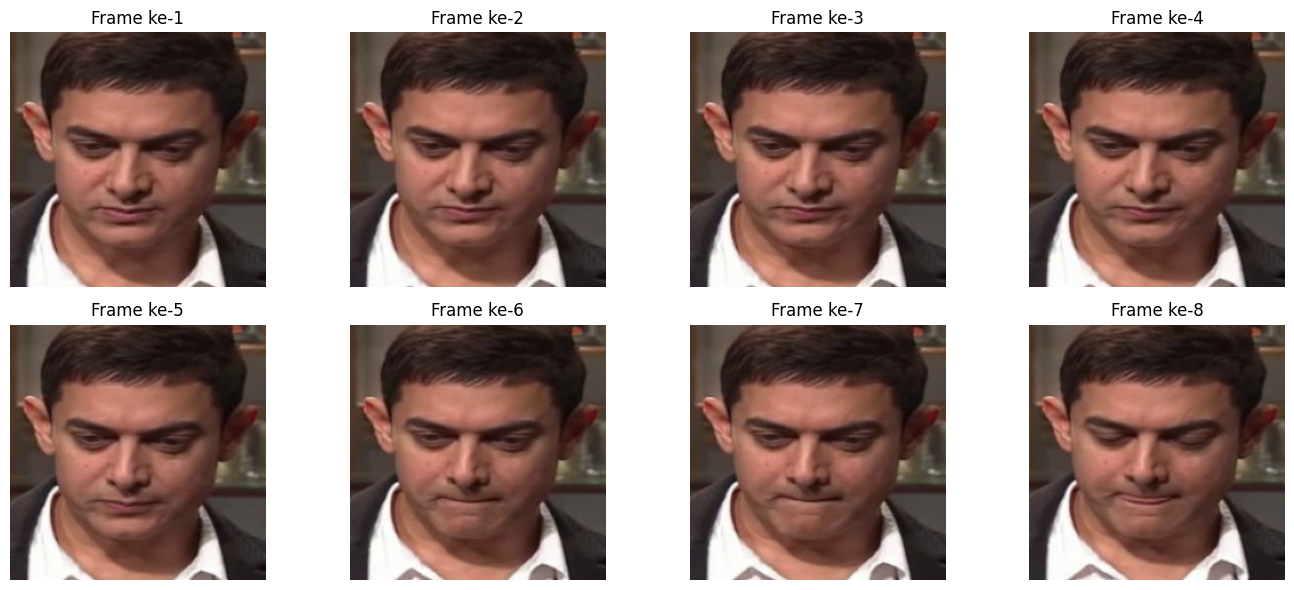

In [14]:
def denormalize_image(img_tensor, mean=NORM_MEAN, std=NORM_STD):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    return img

first_clip = sample_clips[0]
num_show = min(8, first_clip.shape[0])

fig, axes = plt.subplots(2, math.ceil(num_show / 2), figsize=(14, 6))
axes = np.array(axes).reshape(-1)

for i in range(num_show):
    axes[i].imshow(denormalize_image(first_clip[i]))
    axes[i].set_title(f"Frame ke-{i+1}")
    axes[i].axis("off")

for i in range(num_show, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### 15. Focal Loss & Labels

In [15]:
if CFG.num_frames % 2 != 0:
    raise ValueError(
        f"CFG.num_frames={CFG.num_frames} tidak kompatibel dengan tubelet temporal 2."
    )

id2label = {0: "real", 1: "fake"}
label2id = {"real": 0, "fake": 1}


class FocalLoss(nn.Module):
    """
    Focal Loss untuk klasifikasi multi-class berbasis logits.

    Pada notebook ini:
    - logits: [B, 2]
    - label : 0 = real, 1 = fake
    
    Rumus umum:
        FL = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2.0, alpha=None, reduction: str = "mean"):
        super().__init__()

        if gamma < 0:
            raise ValueError("gamma harus bernilai >= 0.")

        if reduction not in {"mean", "sum", "none"}:
            raise ValueError("reduction harus salah satu dari: 'mean', 'sum', atau 'none'.")

        self.gamma = gamma
        self.reduction = reduction

        if alpha is None:
            self.register_buffer("alpha", None)
        else:
            alpha = torch.as_tensor(alpha, dtype=torch.float32)
            self.register_buffer("alpha", alpha)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.long()

        log_probs = torch.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)

        target_indices = targets.unsqueeze(1)

        log_pt = log_probs.gather(1, target_indices).squeeze(1)
        pt = probs.gather(1, target_indices).squeeze(1)

        focal_factor = (1.0 - pt).pow(self.gamma)
        loss = -focal_factor * log_pt

        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            loss = alpha_t * loss

        if self.reduction == "mean":
            return loss.mean()

        if self.reduction == "sum":
            return loss.sum()

        return loss

### 16. Linear Decay Scheduler

In [16]:
class LinearDecayLR(_LRScheduler):
    def __init__(self, optimizer, n_epoch, start_decay, last_epoch=-1, booster=2):
        self.start_decay = start_decay
        self.n_epoch = n_epoch
        self.booster = booster
        super(LinearDecayLR, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        last_epoch = self.last_epoch
        n_epoch = self.n_epoch
        b_lr = self.base_lrs[-1]

        if last_epoch > 0:
            try:
                cur_lr = self.get_last_lr()
            except Exception:
                cur_lr = b_lr * self.booster

        start_decay = self.start_decay

        if last_epoch >= start_decay:
            lr = b_lr * self.booster - (b_lr * self.booster) / (n_epoch - start_decay) * (last_epoch - start_decay)
        else:
            if last_epoch < start_decay:
                lr = b_lr + (b_lr * self.booster - b_lr) / start_decay * last_epoch
            else:
                lr = cur_lr

        self._last_lr = [lr]
        print(f"Active Learning Rate --- {lr}")
        return [lr for _ in self.optimizer.param_groups]

### 17. Model Init & Optimizer

In [17]:
id2label = {0: "real", 1: "fake"}
label2id = {"real": 0, "fake": 1}

use_local_checkpoint = (MODEL_CHECKPOINT / "config.json").exists()

if use_local_checkpoint:
    model_source = str(MODEL_CHECKPOINT)
    print("Menggunakan checkpoint VideoMAE lokal:", model_source)
else:
    model_source = "MCG-NJU/videomae-base-finetuned-ssv2"
    print("Checkpoint lokal tidak ditemukan. Menggunakan HuggingFace model:", model_source)

config = VideoMAEConfig.from_pretrained(
    model_source,
    local_files_only=use_local_checkpoint,
)

config.num_frames = CFG.num_frames
config.image_size = CFG.final_image_size
config.num_labels = 2
config.id2label = id2label
config.label2id = label2id

model = VideoMAEForVideoClassification.from_pretrained(
    model_source,
    config=config,
    ignore_mismatched_sizes=True,
    local_files_only=use_local_checkpoint,
)

model = model.to(DEVICE)

print("config.num_frames   :", model.config.num_frames)
print("config.image_size   :", model.config.image_size)
print("config.patch_size   :", model.config.patch_size)
print("config.tubelet_size :", model.config.tubelet_size)

if USE_FOCAL_LOSS:
    if USE_FOCAL_ALPHA:
        label_counts_series = train_split_df["label"].astype(int).value_counts().sort_index()

        class_counts = torch.tensor(
            [
                label_counts_series.get(0, 0),
                label_counts_series.get(1, 0),
            ],
            dtype=torch.float32,
        )

        if torch.any(class_counts == 0):
            raise ValueError(
                f"Terdapat kelas dengan jumlah sampel 0 pada data latih: {class_counts.tolist()}"
            )

        focal_alpha = class_counts.sum() / (len(class_counts) * class_counts)
        focal_alpha = focal_alpha / focal_alpha.mean()

        print("Menggunakan Focal Loss dengan alpha otomatis.")
        print("Class counts [real, fake] :", class_counts.tolist())
        print("Focal alpha  [real, fake] :", focal_alpha.tolist())

    else:
        focal_alpha = None
        print("Menggunakan Focal Loss tanpa alpha.")

    criterion = FocalLoss(
        gamma=FOCAL_GAMMA,
        alpha=focal_alpha,
        reduction="mean",
    ).to(DEVICE)

else:
    criterion = nn.CrossEntropyLoss()
    print("Menggunakan CrossEntropyLoss.")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer=optimizer,
    T_max=EPOCHS,
    eta_min=ETA_MIN,
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_GRAD_SCALER)

print("Checkpoint aktif    :", model_source)
print("Loss aktif          :", criterion.__class__.__name__)
print("USE_GRAD_SCALER     :", USE_GRAD_SCALER)
print("Optimizer           :", optimizer.__class__.__name__)
print("Base learning rate  :", LR)
print("Weight decay        :", WEIGHT_DECAY)
print("Scheduler           :", scheduler.__class__.__name__)
print("ETA_MIN             :", ETA_MIN)

Menggunakan checkpoint VideoMAE lokal: /shared-docker/celebdfv2_runtime/kaggle_models/videomae-base-finetuned-ssv2/videomae-base-finetuned-ssv2


Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at /shared-docker/celebdfv2_runtime/kaggle_models/videomae-base-finetuned-ssv2/videomae-base-finetuned-ssv2 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([174, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([174]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


config.num_frames   : 16
config.image_size   : 224
config.patch_size   : 16
config.tubelet_size : 2
Menggunakan CrossEntropyLoss.
Checkpoint aktif    : /shared-docker/celebdfv2_runtime/kaggle_models/videomae-base-finetuned-ssv2/videomae-base-finetuned-ssv2
Loss aktif          : CrossEntropyLoss
USE_GRAD_SCALER     : False
Optimizer           : AdamW
Base learning rate  : 5e-05
Weight decay        : 0.0001
Scheduler           : CosineAnnealingLR
ETA_MIN             : 0.0


### 18. Metrics

In [18]:
def compute_classification_metrics(y_true, y_pred, y_prob_fake=None):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "precision_weighted": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "recall_weighted": recall_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "cm": cm,
        "y_pred": y_pred,
        "classification_report_text": classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=["real", "fake"],
            digits=4,
            zero_division=0,
        ),
        "classification_report_dict": classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=["real", "fake"],
            digits=4,
            zero_division=0,
            output_dict=True,
        ),
    }

    if y_prob_fake is not None:
        try:
            roc_auc = roc_auc_score(y_true, y_prob_fake)
            fpr, tpr, thresholds = roc_curve(
                y_true,
                y_prob_fake,
                pos_label=POSITIVE_CLASS_INDEX,
            )
        except ValueError:
            roc_auc = float("nan")
            fpr = np.asarray([])
            tpr = np.asarray([])
            thresholds = np.asarray([])

        metrics["roc_auc"] = roc_auc
        metrics["fpr"] = fpr
        metrics["tpr"] = tpr
        metrics["thresholds"] = thresholds

    return metrics

### 19. Train/Eval Functions

In [19]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    scaler,
    device,
    epoch: int | None = None,
    total_epochs: int | None = None,
):
    model.train()

    running_loss = 0.0
    total_samples = 0
    all_y_true = []
    all_y_pred = []
    all_prob_fake = []

    desc = f"Train {epoch:02d}/{total_epochs}" if epoch is not None else "Train"

    progress_bar = tqdm(
        loader,
        desc=desc,
        total=len(loader),
        dynamic_ncols=True,
        leave=False,
    )

    for batch_idx, (clips, labels, meta) in enumerate(progress_bar, start=1):
        batch_start = time.time()

        clips = clips.to(device, non_blocking=True)    # [B, T, C, H, W]
        labels = labels.to(device, non_blocking=True)  # [B]

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            outputs = model(pixel_values=clips)
            logits = outputs.logits
            loss = criterion(logits, labels)

        probs = torch.softmax(logits.detach().float(), dim=1)
        preds = torch.argmax(probs, dim=1)

        all_y_true.extend(labels.detach().cpu().numpy().tolist())
        all_y_pred.extend(preds.detach().cpu().numpy().tolist())
        all_prob_fake.extend(probs[:, 1].detach().cpu().numpy().tolist())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

        avg_loss = running_loss / max(total_samples, 1)
        batch_time = time.time() - batch_start

        progress_bar.set_postfix({
            "loss": f"{avg_loss:.4f}",
            "batch_s": f"{batch_time:.1f}",
        })

        del clips, labels, outputs, logits, loss, probs

    train_metrics = compute_classification_metrics(all_y_true, all_y_pred, all_prob_fake)
    train_metrics["loss"] = running_loss / max(total_samples, 1)

    return train_metrics


@torch.no_grad()
def evaluate_clip_level(
    model,
    loader,
    criterion,
    device,
    epoch: int | None = None,
    total_epochs: int | None = None,
    split_name: str = "Valid",
):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_y_true = []
    all_y_pred = []
    all_probs = []
    all_clip_dirs = []

    if epoch is not None and total_epochs is not None:
        desc = f"{split_name} {epoch:02d}/{total_epochs}"
    else:
        desc = split_name

    progress_bar = tqdm(
        loader,
        desc=desc,
        total=len(loader),
        dynamic_ncols=True,
        leave=False,
    )

    for batch_idx, (clips, labels, meta) in enumerate(progress_bar, start=1):
        batch_start = time.time()

        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            outputs = model(pixel_values=clips)
            logits = outputs.logits
            loss = criterion(logits, labels)

        probs = torch.softmax(logits.float(), dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true = labels.detach().cpu().numpy()
        y_pred = preds.detach().cpu().numpy()
        prob_np = probs.detach().cpu().numpy()

        all_y_true.extend(y_true.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_probs.append(prob_np)
        all_clip_dirs.extend(meta["clip_dir"])

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

        avg_loss = running_loss / max(total_samples, 1)
        batch_time = time.time() - batch_start

        progress_bar.set_postfix({
            "loss": f"{avg_loss:.4f}",
            "batch_s": f"{batch_time:.1f}",
        })

        del clips, labels, outputs, logits, loss, probs

    all_probs = np.concatenate(all_probs, axis=0)

    metric_dict = compute_classification_metrics(all_y_true, all_y_pred, all_probs[:, 1])
    metric_dict["loss"] = running_loss / max(total_samples, 1)
    metric_dict["y_true"] = np.array(all_y_true)
    metric_dict["y_pred"] = np.array(all_y_pred)
    metric_dict["y_prob_real"] = all_probs[:, 0]
    metric_dict["y_prob_fake"] = all_probs[:, 1]
    metric_dict["clip_dirs"] = list(all_clip_dirs)

    return metric_dict

### 20. W&B Init

In [20]:
# INISIALISASI WEIGHTS & BIASES
wandb_run = None

def setup_wandb_login():
    if not USE_WANDB:
        return

    os.environ["WANDB_MODE"] = WANDB_MODE
    print(f"W&B mode: {os.environ['WANDB_MODE']}")

def build_wandb_config():
    return {
        "experiment_code": CFG.code,
        "experiment_description": CFG.description,
        "model_kind": MODEL_KIND,
        "num_classes": 2,
        "class_0": "real",
        "class_1": "fake",
        "source_clip_len": SOURCE_CLIP_LEN,
        "num_frames": CFG.num_frames,
        "stride": CFG.stride,
        "final_image_size": CFG.final_image_size,
        "downscale_first": CFG.downscale_first,
        "batch_size_clips": BATCH_SIZE_CLIPS,
        "epochs": EPOCHS,
        "learning_rate": LR,
        "weight_decay": WEIGHT_DECAY,
        "optimizer": optimizer.__class__.__name__,
        "scheduler": SCHEDULER_NAME,
        "scheduler_start_decay": SCHEDULER_START_DECAY,
        "scheduler_booster": SCHEDULER_BOOSTER,
        "base_learning_rate": LR,
        "max_active_learning_rate": LR * SCHEDULER_BOOSTER,
        "use_early_stopping": USE_EARLY_STOPPING,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE if USE_EARLY_STOPPING else None,
        "loss_name": criterion.__class__.__name__,
        "use_focal_loss": USE_FOCAL_LOSS,
        "focal_gamma": FOCAL_GAMMA if USE_FOCAL_LOSS else None,
        "use_focal_alpha": USE_FOCAL_ALPHA if USE_FOCAL_LOSS else None,
        "train_size": len(train_dataset),
        "val_size": len(val_dataset),
        "test_size": len(test_dataset),
        "normalization_mean": NORM_MEAN,
        "normalization_std": NORM_STD,
        "checkpoint_selected_by": "val_accuracy",
        "evaluation_level": "clip_level",
    }


if USE_WANDB:
    setup_wandb_login()

    if wandb.run is not None:
        wandb.finish()

    wandb_run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=WANDB_RUN_NAME,
        group=WANDB_GROUP,
        tags=WANDB_TAGS,
        config=build_wandb_config(),
        dir=str(OUTPUT_DIR),
        reinit=True,
    )

    wandb_run.define_metric("epoch")
    wandb_run.define_metric("train/*", step_metric="epoch")
    wandb_run.define_metric("valid/*", step_metric="epoch")
    wandb_run.define_metric("lr", step_metric="epoch")
    wandb_run.define_metric("time/*", step_metric="epoch")
    wandb_run.define_metric("test/*")

    print("W&B run aktif:", wandb_run.name)
else:
    print("W&B dinonaktifkan.")

W&B mode: online


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: afenmarbun (afenmarbun-institut-teknologi-sumatera) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


W&B run aktif: C01_spatiotemporal_videomae_CelebDFV2


### 21. Training Loop & Checkpoint

In [21]:
history = []
best_state = None
best_epoch = 0
best_val_accuracy = float("-inf")
best_val_loss_at_best_acc = None
patience_counter = 0

checkpoint_path = OUTPUT_DIR / f"best_{CFG.code}_videomae.pt"

start_time = time.time()

print("Mulai training...", flush=True)
print("Experiment code :", CFG.code, flush=True)
print("Device          :", DEVICE, flush=True)
print("Checkpoint path :", checkpoint_path, flush=True)
print("Jumlah epoch    :", EPOCHS, flush=True)
print("Train batches   :", len(train_loader), flush=True)
print("Valid batches   :", len(val_loader), flush=True)

epoch_bar = tqdm(
    range(1, EPOCHS + 1),
    desc=f"Training {CFG.code}",
    total=EPOCHS,
    dynamic_ncols=True,
)

for epoch in epoch_bar:
    epoch_start = time.time()

    print(f"\n[{CFG.code}] Mulai epoch {epoch:02d}/{EPOCHS}", flush=True)

    train_result = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
        device=DEVICE,
        epoch=epoch,
        total_epochs=EPOCHS,
    )

    train_loss = train_result["loss"]

    val_result = evaluate_clip_level(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE,
        epoch=epoch,
        total_epochs=EPOCHS,
        split_name="Valid",
    )

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()
    epoch_time_sec = time.time() - epoch_start

    row = {
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "train_accuracy": float(train_result["accuracy"]),
        "train_precision_macro": float(train_result["precision_macro"]),
        "train_recall_macro": float(train_result["recall_macro"]),
        "train_f1_macro": float(train_result["f1_macro"]),
        "train_precision_weighted": float(train_result["precision_weighted"]),
        "train_recall_weighted": float(train_result["recall_weighted"]),
        "train_f1_weighted": float(train_result["f1_weighted"]),

        "val_loss": float(val_result["loss"]),
        "val_accuracy": float(val_result["accuracy"]),
        "val_precision_macro": float(val_result["precision_macro"]),
        "val_recall_macro": float(val_result["recall_macro"]),
        "val_f1_macro": float(val_result["f1_macro"]),
        "val_precision_weighted": float(val_result["precision_weighted"]),
        "val_recall_weighted": float(val_result["recall_weighted"]),
        "val_f1_weighted": float(val_result["f1_weighted"]),

        "lr": float(optimizer.param_groups[0]["lr"]),
        "epoch_time_sec": float(epoch_time_sec),
    }
    history.append(row)
    
    if wandb_run is not None:
        wandb_run.log(
            {
                "epoch": row["epoch"],

                "train/loss": row["train_loss"],
                "train/accuracy": row["train_accuracy"],
                "train/precision_macro": row["train_precision_macro"],
                "train/recall_macro": row["train_recall_macro"],
                "train/f1_macro": row["train_f1_macro"],
                "train/precision_weighted": row["train_precision_weighted"],
                "train/recall_weighted": row["train_recall_weighted"],
                "train/f1_weighted": row["train_f1_weighted"],

                "valid/loss": row["val_loss"],
                "valid/accuracy": row["val_accuracy"],
                "valid/precision_macro": row["val_precision_macro"],
                "valid/recall_macro": row["val_recall_macro"],
                "valid/f1_macro": row["val_f1_macro"],
                "valid/precision_weighted": row["val_precision_weighted"],
                "valid/recall_weighted": row["val_recall_weighted"],
                "valid/f1_weighted": row["val_f1_weighted"],

                "lr": row["lr"],
                "time/epoch_sec": row["epoch_time_sec"],
            },
            step=epoch,
        )

    epoch_bar.set_postfix({
        "train_loss": f"{train_loss:.4f}",
        "val_loss": f"{val_result['loss']:.4f}",
        "val_f1_macro": f"{val_result['f1_macro']:.4f}",
    })

    print(
        f"[{CFG.code}] Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"train_acc={train_result['accuracy']:.4f} | "
        f"train_f1_macro={train_result['f1_macro']:.4f} | "
        f"val_loss={val_result['loss']:.4f} | "
        f"val_acc={val_result['accuracy']:.4f} | "
        f"val_f1_macro={val_result['f1_macro']:.4f} | "
        f"epoch_time={epoch_time_sec/60:.2f} menit",
        flush=True,
    )

    current_val_accuracy = float(val_result["accuracy"])

    if current_val_accuracy > best_val_accuracy:
        best_val_accuracy = current_val_accuracy
        best_val_loss_at_best_acc = float(val_result["loss"])
        best_epoch = int(epoch)
        patience_counter = 0

        model_state_cpu = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        best_state = {
            "epoch": int(epoch),
            "experiment_code": str(CFG.code),
            "experiment_config": dict(CFG.__dict__),
            "model_checkpoint": str(MODEL_CHECKPOINT),
            "checkpoint_selected_by": "val_accuracy",

            "loss_name": str(criterion.__class__.__name__),
            "use_focal_loss": bool(USE_FOCAL_LOSS),
            "focal_gamma": float(FOCAL_GAMMA) if USE_FOCAL_LOSS else None,
            "use_focal_alpha": bool(USE_FOCAL_ALPHA) if USE_FOCAL_LOSS else None,

            "model_state_dict": model_state_cpu,
            
            "best_val_accuracy": float(val_result["accuracy"]),
            "best_val_loss": float(val_result["loss"]),
            "best_val_precision_macro": float(val_result["precision_macro"]),
            "best_val_recall_macro": float(val_result["recall_macro"]),
            "best_val_f1_macro": float(val_result["f1_macro"]),
            "best_val_precision_weighted": float(val_result["precision_weighted"]),
            "best_val_recall_weighted": float(val_result["recall_weighted"]),
            "best_val_f1_weighted": float(val_result["f1_weighted"]),
        }

        torch.save(best_state, checkpoint_path)

        if wandb_run is not None:
            wandb_run.summary["best_epoch"] = int(epoch)
            wandb_run.summary["best/val_accuracy"] = float(val_result["accuracy"])
            wandb_run.summary["best/val_loss"] = float(val_result["loss"])
            wandb_run.summary["best/val_precision_macro"] = float(val_result["precision_macro"])
            wandb_run.summary["best/val_recall_macro"] = float(val_result["recall_macro"])
            wandb_run.summary["best/val_f1_macro"] = float(val_result["f1_macro"])
            wandb_run.summary["best/val_precision_weighted"] = float(val_result["precision_weighted"])
            wandb_run.summary["best/val_recall_weighted"] = float(val_result["recall_weighted"])
            wandb_run.summary["best/val_f1_weighted"] = float(val_result["f1_weighted"])

        print(
            f"  -> checkpoint terbaik disimpan berdasarkan "
            f"val_accuracy={best_val_accuracy:.4f}: {checkpoint_path}",
            flush=True,
        )

    else:
        if USE_EARLY_STOPPING:
            patience_counter += 1

            print(
                f"  -> val_accuracy tidak membaik, "
                f"patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}",
                flush=True,
            )

            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print("\nEarly stopping aktif.", flush=True)
                break

        else:
            print(
                "  -> val_accuracy tidak membaik; early stopping dinonaktifkan, training tetap dilanjutkan.",
                flush=True,
            )

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

total_time = time.time() - start_time

print(f"\nTraining selesai dalam {total_time/60:.2f} menit.", flush=True)
print(f"Best epoch        : {best_epoch}", flush=True)
print(f"Best val_accuracy : {best_val_accuracy:.4f}", flush=True)
print(f"Val loss at best  : {best_val_loss_at_best_acc:.4f}", flush=True)

history_df = pd.DataFrame(history)

history_df = history_df[
    [
        "epoch",
        "train_loss",
        "train_accuracy",
        "train_precision_macro",
        "train_recall_macro",
        "train_f1_macro",
        "train_precision_weighted",
        "train_recall_weighted",
        "train_f1_weighted",

        "val_loss",
        "val_accuracy",
        "val_precision_macro",
        "val_recall_macro",
        "val_f1_macro",
        "val_precision_weighted",
        "val_recall_weighted",
        "val_f1_weighted",

        "lr",
        "epoch_time_sec",
    ]
]

history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

if wandb_run is not None:
    wandb_run.log(
        {
            "training/history_table": wandb.Table(dataframe=history_df)
        },
        step=int(history_df["epoch"].max()),
    )

display(history_df.reset_index(drop=True))

Mulai training...
Experiment code : C01
Device          : cuda
Checkpoint path : /shared-docker/experiments_celebdfv2/spatiotemporal_videomae/C01/best_C01_videomae.pt
Jumlah epoch    : 25
Train batches   : 151
Valid batches   : 38


Training C01:   0% 0/25 [00:00<?, ?it/s]


[C01] Mulai epoch 01/25


Train 01/25:   0% 0/151 [00:04<?, ?it/s]

Valid 01/25:   0% 0/38 [00:00<?, ?it/s]

...

[C01] Epoch 24 | train_loss=0.0013 | train_acc=0.9998 | train_f1_macro=0.9995 | val_loss=0.0999 | val_acc=0.9751 | val_f1_macro=0.9362 | epoch_time=0.99 menit
  -> val_accuracy tidak membaik; early stopping dinonaktifkan, training tetap dilanjutkan.

[C01] Mulai epoch 25/25


Train 25/25:   0% 0/151 [00:00<?, ?it/s]

Valid 25/25:   0% 0/38 [00:00<?, ?it/s]

[C01] Epoch 25 | train_loss=0.0036 | train_acc=0.9988 | train_f1_macro=0.9970 | val_loss=0.1000 | val_acc=0.9751 | val_f1_macro=0.9362 | epoch_time=0.97 menit
  -> val_accuracy tidak membaik; early stopping dinonaktifkan, training tetap dilanjutkan.

Training selesai dalam 27.80 menit.
Best epoch        : 19
Best val_accuracy : 0.9767
Val loss at best  : 0.0865


,epoch,train_loss,train_accuracy,train_precision_macro,train_recall_macro,train_f1_macro,train_precision_weighted,train_recall_weighted,train_f1_weighted,val_loss,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_precision_weighted,val_recall_weighted,val_f1_weighted,lr,epoch_time_sec
0,1,0.323132,0.887248,0.756582,0.556438,0.572299,0.861234,0.887248,0.852432,0.231308,0.908562,0.860406,0.643175,0.691630,0.900675,0.908562,0.889212,4.980287e-05,83.783267
1,2,0.241895,0.913043,0.850780,0.677573,0.726782,0.904292,0.913043,0.898965,0.287218,0.909393,0.788885,0.747342,0.765780,0.903649,0.909393,0.905887,4.921458e-05,70.420099
2,3,0.188242,0.936551,0.884594,0.787521,0.826568,0.932407,0.936551,0.931983,0.201765,0.940150,0.912765,0.780027,0.829579,0.937462,0.940150,0.934444,4.824441e-05,71.304530
3,4,0.146183,0.948201,0.903978,0.833687,0.864274,0.945677,0.948201,0.945736,0.177672,0.921862,0.807289,0.836757,0.821016,0.925995,0.921862,0.923649,4.690767e-05,83.841791
4,5,0.113886,0.958810,0.916011,0.880024,0.896899,0.957542,0.958810,0.957879,0.226895,0.924356,0.960503,0.679577,0.743688,0.930331,0.924356,0.908078,4.522542e-05,64.583330
5,6,0.093078,0.967339,0.942171,0.896273,0.917515,0.966452,0.967339,0.966446,0.230111,0.922693,0.959705,0.672535,0.735551,0.928923,0.922693,0.905495,4.322422e-05,60.000687
6,7,0.084315,0.969212,0.939266,0.909507,0.923673,0.968510,0.969212,0.968672,0.146187,0.948462,0.951264,0.793890,0.850971,0.948757,0.948462,0.943052,4.093560e-05,61.194141
7,8,0.046825,0.983150,0.966640,0.951645,0.958976,0.982963,0.983150,0.983012,0.132897,0.960931,0.949608,0.855856,0.895470,0.960172,0.960931,0.958662,3.839567e-05,60.221822
8,9,0.049636,0.983150,0.968048,0.950124,0.958848,0.982947,0.983150,0.982985,0.104652,0.963425,0.912168,0.912168,0.912168,0.963425,0.963425,0.963425,3.564448e-05,64.084424
9,10,0.031653,0.989599,0.980751,0.968996,0.974774,0.989522,0.989599,0.989534,0.139012,0.960931,0.961037,0.846707,0.893207,0.960939,0.960931,0.958174,3.272542e-05,69.259429


### 22. Training Curves

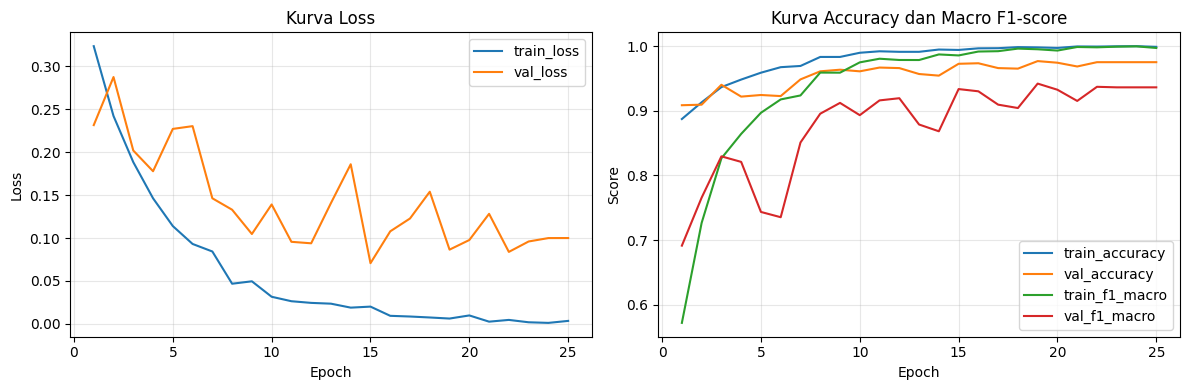

Plot history disimpan: /shared-docker/experiments_celebdfv2/spatiotemporal_videomae/C01/training_history.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_title("Kurva Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="train_accuracy")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="val_accuracy")
axes[1].plot(history_df["epoch"], history_df["train_f1_macro"], label="train_f1_macro")
axes[1].plot(history_df["epoch"], history_df["val_f1_macro"], label="val_f1_macro")
axes[1].set_title("Kurva Accuracy dan Macro F1-score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

history_plot_path = OUTPUT_DIR / "training_history.png"
plt.savefig(history_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Plot history disimpan:", history_plot_path)

### 23. Training Summary

In [23]:
if best_state is None:
    raise RuntimeError(
        "best_state masih None. Artinya belum ada checkpoint yang berhasil disimpan."
    )

summary_df = pd.DataFrame([{
    "experiment_code": CFG.code,
    "experiment_description": CFG.description,
    "model_checkpoint": str(MODEL_CHECKPOINT),
    "checkpoint_path": str(checkpoint_path),
    "num_frames": CFG.num_frames,
    "stride": CFG.stride,
    "final_image_size": CFG.final_image_size,
    "downscale_first": CFG.downscale_first,
    "batch_size_clips": BATCH_SIZE_CLIPS,
    "checkpoint_selected_by": best_state.get("checkpoint_selected_by", "val_accuracy"),
    "loss_name": best_state.get("loss_name", criterion.__class__.__name__),
    "use_focal_loss": best_state.get("use_focal_loss", USE_FOCAL_LOSS),
    "focal_gamma": best_state.get("focal_gamma", FOCAL_GAMMA if USE_FOCAL_LOSS else None),
    "use_focal_alpha": best_state.get("use_focal_alpha", USE_FOCAL_ALPHA if USE_FOCAL_LOSS else None),
    "best_epoch": best_state["epoch"],
    "best_val_accuracy": best_state["best_val_accuracy"],
    "best_val_loss": best_state["best_val_loss"],
    "best_val_precision_macro": best_state["best_val_precision_macro"],
    "best_val_recall_macro": best_state["best_val_recall_macro"],
    "best_val_f1_macro": best_state["best_val_f1_macro"],
    "best_val_precision_weighted": best_state["best_val_precision_weighted"],
    "best_val_recall_weighted": best_state["best_val_recall_weighted"],
    "best_val_f1_weighted": best_state["best_val_f1_weighted"],
}])

summary_df.to_csv(OUTPUT_DIR / "training_summary.csv", index=False)

if wandb_run is not None:
    wandb_run.log({
        "training/summary_table": wandb.Table(dataframe=summary_df)
    })

print("Training summary:")
display(summary_df)

Training summary:


,experiment_code,experiment_description,model_checkpoint,checkpoint_path,num_frames,stride,final_image_size,downscale_first,batch_size_clips,checkpoint_selected_by,...,use_focal_alpha,best_epoch,best_val_accuracy,best_val_loss,best_val_precision_macro,best_val_recall_macro,best_val_f1_macro,best_val_precision_weighted,best_val_recall_weighted,best_val_f1_weighted
0,C01,Celeb-DF v2 fine-tuning ulang menggunakan hype...,/shared-docker/celebdfv2_runtime/kaggle_models...,/shared-docker/experiments_celebdfv2/spatiotem...,16,3,224,None,32,val_accuracy,...,None,19,0.976725,0.086467,0.959911,0.925807,0.941969,0.976297,0.976725,0.976277


### 24. Final Test Evaluation

In [ ]:
# FINAL TESTING PADA DATA TEST
test_output_dir = OUTPUT_DIR / "test_results"
test_output_dir.mkdir(parents=True, exist_ok=True)

if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Checkpoint terbaik tidak ditemukan: {checkpoint_path}\n"
        "Pastikan cell training sudah dijalankan sampai checkpoint tersimpan."
    )

print("Memuat checkpoint terbaik:")
print(checkpoint_path)

try:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )
except TypeError:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
    )

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print("\nInformasi checkpoint:")
print("Experiment code          :", checkpoint.get("experiment_code"))
print("Best epoch               :", checkpoint.get("epoch"))
print("Selected by              :", checkpoint.get("checkpoint_selected_by"))
print("Best val accuracy        :", checkpoint.get("best_val_accuracy"))
print("Best val F1 macro        :", checkpoint.get("best_val_f1_macro"))
print("Best val precision macro :", checkpoint.get("best_val_precision_macro"))
print("Best val recall macro    :", checkpoint.get("best_val_recall_macro"))
print("\nMulai evaluasi pada data test...")

test_result = evaluate_clip_level(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
)

test_metrics = {
    "experiment_code": CFG.code,
    "description": CFG.description,
    "dataset": "Celeb-DF v2",
    "model_kind": MODEL_KIND,
    "checkpoint_path": str(checkpoint_path),
    "best_epoch": int(checkpoint.get("epoch")),
    "checkpoint_selected_by": checkpoint.get("checkpoint_selected_by"),
    "test_loss": float(test_result["loss"]),
    "test_accuracy": float(test_result["accuracy"]),
    "test_precision_macro": float(test_result["precision_macro"]),
    "test_recall_macro": float(test_result["recall_macro"]),
    "test_f1_macro": float(test_result["f1_macro"]),
    "test_precision_weighted": float(test_result["precision_weighted"]),
    "test_recall_weighted": float(test_result["recall_weighted"]),
    "test_f1_weighted": float(test_result["f1_weighted"]),
    "test_roc_auc": float(test_result.get("roc_auc", float("nan"))),
    "test_num_roc_thresholds": int(len(test_result.get("thresholds", []))),
}

print("\n HASIL FINAL TEST : ")
print(f"Test loss                : {test_metrics['test_loss']:.4f}")
print(f"Test accuracy            : {test_metrics['test_accuracy']:.4f}")
print(f"Test precision macro     : {test_metrics['test_precision_macro']:.4f}")
print(f"Test recall macro        : {test_metrics['test_recall_macro']:.4f}")
print(f"Test F1-score macro      : {test_metrics['test_f1_macro']:.4f}")
print(f"Test ROC-AUC             : {test_metrics['test_roc_auc']:.4f}")
print(f"Jumlah threshold ROC     : {test_metrics['test_num_roc_thresholds']}")

print("\nConfusion Matrix")
print("Baris  : label aktual [real, fake]")
print("Kolom  : label prediksi [real, fake]")
print(test_result["cm"])

# SIMPAN METRIK TEST
test_metrics_csv_path = test_output_dir / "test_metrics.csv"
test_metrics_json_path = test_output_dir / "test_metrics.json"

pd.DataFrame([test_metrics]).to_csv(test_metrics_csv_path, index=False)
with open(test_metrics_json_path, "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2)

# SIMPAN PREDIKSI PER KLIP
test_pred_df = pd.DataFrame({
    "clip_dir": test_result["clip_dirs"],
    "y_true": test_result["y_true"].astype(int),
    "y_pred": test_result["y_pred"].astype(int),
    "y_prob_real": test_result["y_prob_real"].astype(float),
    "y_prob_fake": test_result["y_prob_fake"].astype(float),
})

test_pred_df["y_true_label"] = test_pred_df["y_true"].map(IDX_TO_CLASS)
test_pred_df["y_pred_label"] = test_pred_df["y_pred"].map(IDX_TO_CLASS)
test_pred_df["is_correct"] = test_pred_df["y_true"] == test_pred_df["y_pred"]

classification_report_df = pd.DataFrame(test_result["classification_report_dict"]).T
classification_report_path = test_output_dir / "test_classification_report.csv"
classification_report_df.to_csv(classification_report_path)

test_predictions_path = test_output_dir / "test_predictions_clip_level.csv"
test_pred_df.to_csv(test_predictions_path, index=False)

# SIMPAN ROC CURVE DATA
roc_curve_data_path = test_output_dir / "test_roc_curve_data.csv"
if len(test_result.get("fpr", [])) > 0:
    roc_df = pd.DataFrame({
        "fpr": test_result["fpr"],
        "tpr": test_result["tpr"],
        "threshold": test_result["thresholds"],
    })
    roc_df.to_csv(roc_curve_data_path, index=False)

print("Metrik test disimpan              :", test_metrics_csv_path)
print("Prediksi clip-level disimpan      :", test_predictions_path)
print("Classification report disimpan    :", classification_report_path)
print("ROC curve data disimpan           :", roc_curve_data_path if roc_curve_data_path.exists() else "Tidak tersedia")

Memuat checkpoint terbaik:
/shared-docker/experiments_celebdfv2/spatiotemporal_videomae/C01/best_C01_videomae.pt

Informasi checkpoint:
Experiment code          : C01
Best epoch               : 19
Selected by              : val_accuracy
Best val accuracy        : 0.9767248545303409
Best val F1 macro        : 0.9419689619052869
Best val precision macro : 0.959911104738691
Best val recall macro    : 0.9258074365135203

Mulai evaluasi pada data test...


Valid:   0% 0/17 [00:06<?, ?it/s]

### 25. W&B Test Logging

In [ ]:
if wandb_run is not None:
    wandb_run.log({
        "test/loss": test_metrics["test_loss"],
        "test/accuracy": test_metrics["test_accuracy"],
        "test/precision_macro": test_metrics["test_precision_macro"],
        "test/recall_macro": test_metrics["test_recall_macro"],
        "test/f1_macro": test_metrics["test_f1_macro"],
        "test/precision_weighted": test_metrics["test_precision_weighted"],
        "test/recall_weighted": test_metrics["test_recall_weighted"],
        "test/f1_weighted": test_metrics["test_f1_weighted"],
        "test/roc_auc": test_metrics["test_roc_auc"],
        "test/num_roc_thresholds": test_metrics["test_num_roc_thresholds"],
    })

    wandb_run.summary["test/loss"] = test_metrics["test_loss"]
    wandb_run.summary["test/accuracy"] = test_metrics["test_accuracy"]
    wandb_run.summary["test/precision_macro"] = test_metrics["test_precision_macro"]
    wandb_run.summary["test/recall_macro"] = test_metrics["test_recall_macro"]
    wandb_run.summary["test/f1_macro"] = test_metrics["test_f1_macro"]
    wandb_run.summary["test/precision_weighted"] = test_metrics["test_precision_weighted"]
    wandb_run.summary["test/recall_weighted"] = test_metrics["test_recall_weighted"]
    wandb_run.summary["test/f1_weighted"] = test_metrics["test_f1_weighted"]
    wandb_run.summary["test/roc_auc"] = test_metrics["test_roc_auc"]
    wandb_run.summary["test/num_roc_thresholds"] = test_metrics["test_num_roc_thresholds"]

    wandb_run.log({
        "test/predictions_table": wandb.Table(dataframe=test_pred_df),
        "test/classification_report": wandb.Table(dataframe=classification_report_df.reset_index()),
    })

### 26. Confusion Matrix Plot

In [ ]:
# VISUALISASI HASIL TESTING

cm = test_result["cm"]
class_names = [IDX_TO_CLASS[i] for i in sorted(IDX_TO_CLASS.keys())]  # ["real", "fake"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(f"Confusion Matrix {CFG.code} {MODEL_KIND}")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()

confusion_matrix_path = test_output_dir / "test_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=200, bbox_inches="tight")
plt.show()

# ROC Curve
fpr = test_result.get("fpr", np.asarray([]))
tpr = test_result.get("tpr", np.asarray([]))

if len(fpr) > 0 and len(tpr) > 0:
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {test_metrics['test_roc_auc']:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.title(f"ROC Curve {CFG.code} {MODEL_KIND}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    roc_curve_path = test_output_dir / "test_roc_curve.png"
    plt.savefig(roc_curve_path, dpi=200, bbox_inches="tight")
    plt.show()
else:
    roc_curve_path = None
    print("ROC curve tidak dibuat karena FPR/TPR kosong.")

if wandb_run is not None:
    payload = {
        "test/confusion_matrix": wandb.Image(str(confusion_matrix_path)),
    }
    if roc_curve_path is not None:
        payload["test/roc_curve"] = wandb.Image(str(roc_curve_path))
    wandb_run.log(payload)

print("Confusion matrix disimpan:", confusion_matrix_path)
if roc_curve_path is not None:
    print("ROC curve disimpan:", roc_curve_path)

### 27. Misclassified Analysis

In [ ]:
# ANALISIS SAMPEL YANG SALAH PREDIKSI

misclassified_df = test_pred_df[test_pred_df["is_correct"] == False].copy()

print("Jumlah seluruh klip test       :", len(test_pred_df))
print("Jumlah salah prediksi          :", len(misclassified_df))
print("Persentase salah prediksi (%)  :", 100 * len(misclassified_df) / max(len(test_pred_df), 1))

display(
    misclassified_df.sort_values(
        by="y_prob_fake",
        ascending=False,
    ).head(30)
)

misclassified_csv_path = test_output_dir / "test_misclassified_clip_level.csv"
misclassified_df.to_csv(misclassified_csv_path, index=False)

print("Data salah prediksi disimpan:", misclassified_csv_path)

### 28. Grad-CAM Visualization

In [ ]:

# GRAD-CAM UNTUK MODEL SPASIOTEMPORAL VIDEOMAE
# Catatan:
# VideoMAE memproses token spasiotemporal.
# Dengan tubelet_size=2, dua frame yang berdekatan berada pada temporal tube yang sama.
# Oleh karena itu, heatmap frame 0 dan 1 dapat merujuk ke tube temporal yang sama.

gradcam_output_dir = OUTPUT_DIR / "gradcam_results"
gradcam_output_dir.mkdir(parents=True, exist_ok=True)

# Pilih sampel test yang ingin divisualisasikan.
GRADCAM_SAMPLE_INDICES = [0, 1, 2]

# Pilih frame hasil sampling yang ingin divisualisasikan.
GRADCAM_FRAME_INDICES = sorted(set([
    0,
    CFG.num_frames // 2,
    CFG.num_frames - 1,
]))

# Mode target:
# - "predicted": kelas prediksi model
# - "true"     : label aktual
# - "fake"     : kelas fake
# - "real"     : kelas real
GRADCAM_TARGET_MODE = "predicted"

USE_AUG_SMOOTH = False
USE_EIGEN_SMOOTH = True


# MUAT CHECKPOINT TERBAIK
checkpoint_path = OUTPUT_DIR / f"best_{CFG.code}_videomae.pt"
if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Checkpoint terbaik tidak ditemukan: {checkpoint_path}\n"
        "Jalankan training terlebih dahulu sampai checkpoint tersimpan."
    )

print("Memuat checkpoint terbaik untuk Grad-CAM:")
print(checkpoint_path)

try:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )
except TypeError:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
    )

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

for param in model.parameters():
    param.requires_grad_(True)

print("Checkpoint berhasil dimuat.")
print("Best epoch        :", checkpoint.get("epoch"))
print("Best val accuracy :", checkpoint.get("best_val_accuracy"))

class VideoMAEGradCAMWrapper(nn.Module):
    """
    Wrapper agar pytorch-grad-cam dapat digunakan pada VideoMAE.

    pytorch-grad-cam lebih stabil dengan input 4D:
        [B, T*C, H, W]

    Di dalam wrapper, input tersebut diubah kembali menjadi format VideoMAE:
        [B, T, C, H, W]
    """

    def __init__(self, hf_model, num_frames: int):
        super().__init__()
        self.hf_model = hf_model
        self.num_frames = int(num_frames)
        self.num_channels = 3

    def forward(self, input_tensor):
        """
        input_tensor untuk Grad-CAM:
            [B, T*C, H, W]

        output:
            logits [B, num_labels]
        """
        if input_tensor.ndim != 4:
            raise ValueError(
                "Input Grad-CAM harus berbentuk 4D [B, T*C, H, W], "
                f"tetapi diperoleh shape {tuple(input_tensor.shape)}."
            )

        b, tc, h, w = input_tensor.shape
        expected_channels = self.num_frames * self.num_channels

        if tc != expected_channels:
            raise ValueError(
                f"Jumlah channel input Grad-CAM tidak sesuai. "
                f"Diperoleh {tc}, seharusnya {expected_channels} "
                f"untuk T={self.num_frames} dan C=3."
            )

        pixel_values = input_tensor.view(
            b,
            self.num_frames,
            self.num_channels,
            h,
            w,
        )

        outputs = self.hf_model(pixel_values=pixel_values)
        return outputs.logits


gradcam_model = VideoMAEGradCAMWrapper(
    hf_model=model,
    num_frames=CFG.num_frames,
).to(DEVICE)

gradcam_model.eval()
print("Format input Grad-CAM yang digunakan:")
print(f"[B, T*C, H, W] = [1, {CFG.num_frames * 3}, {CFG.final_image_size}, {CFG.final_image_size}]")


def get_videomae_target_layer(hf_model):
    """
    Mengambil target layer untuk Grad-CAM pada VideoMAE.

    Prioritas:
    1. layernorm_before pada encoder block terakhir.
    2. output.dense pada encoder block terakhir.
    3. layernorm akhir pada VideoMAE, jika tersedia.
    """
    try:
        last_layer = hf_model.videomae.encoder.layer[-1]

        if hasattr(last_layer, "layernorm_before"):
            return last_layer.layernorm_before

        if hasattr(last_layer, "output") and hasattr(last_layer.output, "dense"):
            return last_layer.output.dense

        if hasattr(hf_model.videomae, "layernorm"):
            return hf_model.videomae.layernorm

    except Exception as exc:
        raise AttributeError(
            "Gagal mengambil target layer VideoMAE untuk Grad-CAM. "
            "Cek struktur model dengan print(model)."
        ) from exc

    raise AttributeError(
        "Target layer Grad-CAM tidak ditemukan. "
        "Cek struktur model dengan print(model)."
    )


target_layers = [get_videomae_target_layer(model)]

print("Target layer Grad-CAM:")
print(target_layers[0])

temporal_patches = CFG.num_frames // model.config.tubelet_size
grid_h = CFG.final_image_size // model.config.patch_size
grid_w = CFG.final_image_size // model.config.patch_size
expected_tokens = temporal_patches * grid_h * grid_w

print("\nValidasi konfigurasi token Grad-CAM:")
print("num_frames        :", CFG.num_frames)
print("tubelet_size      :", model.config.tubelet_size)
print("temporal_patches  :", temporal_patches)
print("patch_size        :", model.config.patch_size)
print("grid_h x grid_w   :", grid_h, "x", grid_w)
print("expected_tokens   :", expected_tokens)

if CFG.num_frames % model.config.tubelet_size != 0:
    raise ValueError(
        f"CFG.num_frames={CFG.num_frames} tidak habis dibagi "
        f"tubelet_size={model.config.tubelet_size}."
    )


# RESHAPE TRANSFORM UNTUK TOKEN SPASIOTEMPORAL VIDEOMAE
def make_videomae_reshape_transform(
    frame_index: int,
    num_frames: int,
    image_size: int,
    patch_size: int,
    tubelet_size: int,
):
    """
    Mengubah token VideoMAE [B, N, C] menjadi feature map 2D [B, C, H, W]
    untuk temporal tube yang sesuai dengan frame_index.

    Untuk E01:
    - num_frames = 16
    - tubelet_size = 2
    - temporal_patches = 8
    - image_size = 224
    - patch_size = 16
    - spatial grid = 14 x 14
    """

    temporal_patches = num_frames // tubelet_size
    grid_h = image_size // patch_size
    grid_w = image_size // patch_size
    expected_tokens = temporal_patches * grid_h * grid_w

    tube_index = min(frame_index // tubelet_size, temporal_patches - 1)

    def reshape_transform(tensor):
        # tensor umumnya berbentuk [B, N, C]
        if tensor.ndim != 3:
            raise ValueError(
                f"Output target layer diharapkan berdimensi 3 [B, N, C], "
                f"tetapi diperoleh shape {tuple(tensor.shape)}."
            )

        # Jika ada token tambahan seperti class token, buang token awal.
        if tensor.shape[1] == expected_tokens + 1:
            tensor_wo_extra = tensor[:, 1:, :]
        elif tensor.shape[1] > expected_tokens:
            tensor_wo_extra = tensor[:, -expected_tokens:, :]
        elif tensor.shape[1] == expected_tokens:
            tensor_wo_extra = tensor
        else:
            raise ValueError(
                f"Jumlah token tidak sesuai. Diperoleh {tensor.shape[1]}, "
                f"expected minimal {expected_tokens}."
            )

        result = tensor_wo_extra.reshape(
            tensor_wo_extra.size(0),
            temporal_patches,
            grid_h,
            grid_w,
            tensor_wo_extra.size(2),
        )

        # Ambil satu temporal tube sesuai frame yang divisualisasikan.
        result = result[:, tube_index, :, :, :]  # [B, H, W, C]
        result = result.permute(0, 3, 1, 2)      # [B, C, H, W]

        return result

    return reshape_transform


@torch.no_grad()
def get_clip_prediction_videomae(model, clip_tensor, device):
    """
    Menghasilkan prediksi tingkat klip dari VideoMAE.

    Input:
        clip_tensor: [T, C, H, W]

    Output:
        clip_prob  : probabilitas tingkat klip [2]
        pred_class : kelas prediksi tingkat klip
    """
    model.eval()

    pixel_values = clip_tensor.unsqueeze(0).to(device)  # [1, T, C, H, W]

    outputs = model(pixel_values=pixel_values)
    logits = outputs.logits[0]  # [2]

    clip_prob = torch.softmax(logits.float(), dim=0)
    pred_class = int(torch.argmax(clip_prob).item())

    return clip_prob.detach().cpu(), pred_class


def resolve_gradcam_target_class(mode, pred_class, true_label):
    if mode == "predicted":
        return int(pred_class)

    if mode == "true":
        return int(true_label)

    if mode == "fake":
        return CLASS_TO_IDX["fake"]

    if mode == "real":
        return CLASS_TO_IDX["real"]

    raise ValueError(
        "GRADCAM_TARGET_MODE harus salah satu dari: "
        "'predicted', 'true', 'fake', atau 'real'."
    )


def make_gradcam_for_one_frame(
    gradcam_model,
    target_layers,
    clip_tensor,
    frame_index,
    target_class,
):
    """
    Membuat Grad-CAM untuk satu frame pada satu klip VideoMAE.

    clip_tensor asli:
        [T, C, H, W]

    Untuk pytorch-grad-cam, tensor diubah menjadi:
        [1, T*C, H, W]

    Di dalam wrapper, tensor tersebut dikembalikan menjadi:
        [1, T, C, H, W]
    """
    if clip_tensor.ndim != 4:
        raise ValueError(
            f"clip_tensor harus berbentuk [T, C, H, W], "
            f"tetapi diperoleh shape {tuple(clip_tensor.shape)}."
        )

    t, c, h, w = clip_tensor.shape

    if t != CFG.num_frames:
        raise ValueError(
            f"Jumlah frame tidak sesuai. Diperoleh {t}, "
            f"seharusnya {CFG.num_frames}."
        )

    if c != 3:
        raise ValueError(
            f"Jumlah channel tidak sesuai. Diperoleh {c}, seharusnya 3."
        )

    reshape_transform = make_videomae_reshape_transform(
        frame_index=frame_index,
        num_frames=CFG.num_frames,
        image_size=CFG.final_image_size,
        patch_size=model.config.patch_size,
        tubelet_size=model.config.tubelet_size,
    )

    # Penting:
    # pytorch-grad-cam mengharapkan input 4D agar target_size menjadi 2D.
    # Format [1, T*C, H, W] akan dikembalikan ke [1, T, C, H, W]
    # di dalam VideoMAEGradCAMWrapper.
    input_tensor = clip_tensor.contiguous().view(1, t * c, h, w).to(DEVICE)

    targets = [ClassifierOutputTarget(target_class)]

    cam = GradCAM(
        model=gradcam_model,
        target_layers=target_layers,
        reshape_transform=reshape_transform,
    )

    try:
        gradcam_model.zero_grad(set_to_none=True)

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets,
            aug_smooth=USE_AUG_SMOOTH,
            eigen_smooth=USE_EIGEN_SMOOTH,
        )

        return grayscale_cam[0]

    finally:
        del cam, input_tensor
        gc.collect()

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

def denormalize_image(tensor_img):
    """
    Mengubah tensor citra ter-normalisasi [C, H, W]
    menjadi citra RGB [H, W, C] pada rentang [0, 1].
    """
    img = tensor_img.detach().cpu().clone()

    mean = torch.tensor(NORM_MEAN, dtype=img.dtype).view(3, 1, 1)
    std = torch.tensor(NORM_STD, dtype=img.dtype).view(3, 1, 1)

    img = img * std + mean
    img = torch.clamp(img, 0.0, 1.0)

    img = img.permute(1, 2, 0).numpy()

    return img

# EKSEKUSI GRAD-CAM
valid_sample_indices = [
    idx for idx in GRADCAM_SAMPLE_INDICES
    if 0 <= idx < len(test_dataset)
]

if len(valid_sample_indices) == 0:
    raise ValueError(
        "Tidak ada indeks sampel Grad-CAM yang valid. "
        f"Panjang test_dataset = {len(test_dataset)}."
    )

for sample_idx in valid_sample_indices:
    clip_tensor, label_tensor, meta = test_dataset[sample_idx]

    true_label = int(label_tensor.item())
    clip_prob, pred_class = get_clip_prediction_videomae(
        model=model,
        clip_tensor=clip_tensor,
        device=DEVICE,
    )

    target_class = resolve_gradcam_target_class(
        mode=GRADCAM_TARGET_MODE,
        pred_class=pred_class,
        true_label=true_label,
    )

    print("\n==================================================")
    print("Sample index      :", sample_idx)
    print("Clip dir          :", meta["clip_dir"])
    print("True label        :", IDX_TO_CLASS[true_label])
    print("Pred label        :", IDX_TO_CLASS[pred_class])
    print("Target Grad-CAM   :", IDX_TO_CLASS[target_class])
    print("Prob real         :", float(clip_prob[0]))
    print("Prob fake         :", float(clip_prob[1]))
    print("Sampled indices   :", meta["sampled_indices"].tolist())

    fig, axes = plt.subplots(
        1,
        len(GRADCAM_FRAME_INDICES),
        figsize=(5 * len(GRADCAM_FRAME_INDICES), 5),
    )

    if len(GRADCAM_FRAME_INDICES) == 1:
        axes = [axes]

    for ax, frame_idx in zip(axes, GRADCAM_FRAME_INDICES):
        if frame_idx < 0 or frame_idx >= clip_tensor.shape[0]:
            ax.axis("off")
            ax.set_title(f"Frame {frame_idx} tidak valid")
            continue

        grayscale_cam = make_gradcam_for_one_frame(
            gradcam_model=gradcam_model,
            target_layers=target_layers,
            clip_tensor=clip_tensor,
            frame_index=frame_idx,
            target_class=target_class,
        )

        rgb_img = denormalize_image(clip_tensor[frame_idx])
        cam_image = show_cam_on_image(
            rgb_img.astype(np.float32),
            grayscale_cam,
            use_rgb=True,
        )

        original_frame_index = int(meta["sampled_indices"][frame_idx].item())
        temporal_tube = frame_idx // model.config.tubelet_size

        ax.imshow(cam_image)
        ax.axis("off")
        ax.set_title(
            f"Frame idx {frame_idx}\n"
            f"Original {original_frame_index}\n"
            f"Tube {temporal_tube}"
        )

        save_path = (
            gradcam_output_dir
            / f"sample_{sample_idx:04d}_frame_{frame_idx:02d}_target_{IDX_TO_CLASS[target_class]}.png"
        )

        cv2.imwrite(
            str(save_path),
            cv2.cvtColor(cam_image, cv2.COLOR_RGB2BGR),
        )

    plt.suptitle(
        f"VideoMAE Grad-CAM | sample={sample_idx} | "
        f"true={IDX_TO_CLASS[true_label]} | "
        f"pred={IDX_TO_CLASS[pred_class]} | "
        f"target={IDX_TO_CLASS[target_class]}",
        y=1.05,
    )

    plt.tight_layout()
    plt.show()

print("\nGrad-CAM selesai.")
print("Folder output:", gradcam_output_dir)

### 29. Log W&B Artifact

In [ ]:
# LOG ARTIFACT HASIL EKSPERIMEN KE W&B

def log_experiment_artifact_to_wandb():
    if wandb_run is None:
        return

    artifact_name = sanitize_wandb_name(f"{WANDB_RUN_NAME}_outputs")

    artifact = wandb.Artifact(
        name=artifact_name,
        type="experiment-output",
        metadata={
            "experiment_code": CFG.code,
            "model_kind": MODEL_KIND,
            "num_frames": CFG.num_frames,
            "stride": CFG.stride,
            "final_image_size": CFG.final_image_size,
            "checkpoint_selected_by": "val_accuracy",
        },
    )

    candidate_files = [
        checkpoint_path,
        OUTPUT_DIR / "training_history.csv",
        OUTPUT_DIR / "training_summary.csv",
        test_output_dir / "test_metrics.csv",
        test_output_dir / "test_metrics.json",
        test_output_dir / "test_predictions_clip_level.csv",
        test_output_dir / "test_classification_report.csv",
        test_output_dir / "test_confusion_matrix.png",
        test_output_dir / "test_roc_curve.png",
        test_output_dir / "test_roc_curve_data.csv",
        test_output_dir / "test_misclassified_clip_level.csv",
    ]

    for file_path in candidate_files:
        file_path = Path(file_path)
        if file_path.exists():
            artifact.add_file(str(file_path))

    gradcam_dir = OUTPUT_DIR / "gradcam_results"
    if gradcam_dir.exists():
        artifact.add_dir(str(gradcam_dir), name="gradcam_results")

    wandb_run.log_artifact(artifact)
    print("Artifact W&B berhasil dilog:", artifact_name)

log_experiment_artifact_to_wandb()

if wandb_run is not None:
    wandb_run.finish()
    print("W&B run selesai.")